# **DESCRIPCIÓN DEL CASO**

**Renovación de préstamo**

Desde varios meses atrás una financiera ha identificado que existe una oportunidad comercial de renovar el préstamo a los clientes. Y esto resulta ser más  exitosos si se llega antes que las financieras competidoras.
Por ello a partir, de la información histórica de llamadas de renovación de prestamos se quiere identificar el perfil de los clientes más interesados en una renovación.


Para lograr esta labor se ha provisto a los analistas de Marketing información  histórica de 2 meses de ventas vía el call e información de la entidad financiera de los clientes


***Diccionario***

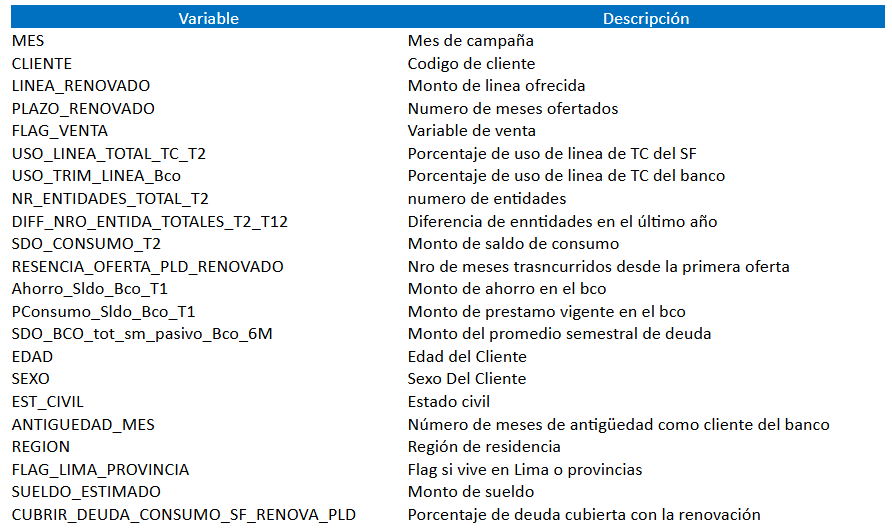

# **0) Setup**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier # Added this import
from sklearn.ensemble import RandomForestClassifier # Added this import

from xgboost import XGBClassifier
import xgboost as xgb
import missingno as msno

np.random.seed(42)

# **1) Carga de datos**



In [ ]:
#Carga de Dataset
df = pd.read_csv('Dataset Renovacion_prestamo.csv',sep=";")
df.head(10)

,MES,CLIENTE,LINEA_RENOVADO,PLAZO_RENOVADO,FLAG_VENTA,USO_LINEA_TOTAL_TC_T2,USO_TRIM_LINEA_BBVA,NR_ENTIDADES_TOTAL_T2,DIFF_NRO_ENTIDA_TOTALES_T2_T12,SDO_CONSUMO_T2,...,PConsumo_Sldo_Bco_T1,SDO_BCO_tot_sm_pasivo_Bco_6M,EDAD,SEXO,EST_CIVIL,ANTIGUEDAD_MES,REGION,FLAG_LIMA_PROVINCIA,SUELDO_ESTIMADO,CUBRIR_DEUDA_CONSUMO_SF_RENOVA_PLD
0,201506,1,3770,12,0,0.000000,0.000000,1,-1,271.12,...,457,3754.333333,25.0,M,S,23.0,LIMA NORTE,1,3531.00,0.071915
1,201506,2,1300,6,0,0.000000,0.000000,1,0,11200.00,...,11200,1581.333333,33.0,M,S,56.0,LIMA ESTE,1,1322.00,8.615380
2,201506,3,7800,36,0,0.429507,0.225615,5,-2,20156.45,...,4778,10241.000000,26.0,M,S,20.0,LIMA MODERNA,1,4234.00,2.584160
3,201506,4,6630,12,0,0.000000,0.000000,1,1,20485.14,...,0,5797.333333,51.0,M,S,166.0,NORTE,0,6647.00,3.089760
4,201506,5,15497,36,1,NaN,NaN,1,0,1682.83,...,1935,16755.333330,35.0,M,C,55.0,NORTE,0,2094.00,0.108590
5,201506,6,13130,36,0,0.207272,0.000000,2,-2,5047.05,...,4186,8725.833333,27.0,M,S,55.0,LIMA NORTE,1,2523.00,0.384390
6,201506,7,13000,24,0,0.439277,0.528205,2,-1,9858.13,...,6621,8193.833333,26.0,M,S,42.0,LIMA NORTE,1,4459.00,0.758317
7,201506,8,3900,12,0,NaN,NaN,3,-2,2172.74,...,1865,11525.750000,26.0,M,S,60.0,LIMA SUR,1,1187.66,0.557112
8,201506,9,6106,36,0,0.000000,0.000000,1,3,3607.29,...,3624,1169.333333,24.0,M,C,62.0,CENTRO,0,2676.00,0.590777
9,201506,10,3900,12,0,NaN,NaN,1,-1,1093.70,...,1317,1828.166666,23.0,F,S,35.0,LIMA MODERNA,1,2140.25,0.280435


# **2) Exploración de Datos**

Checklist mínimo:

- Tamaño
- Columnas
- Target (balance / proporción)
- Tipos de datos
- Resumen estadistico
- Nulos / Duplicados


In [ ]:
#Tamaño de mi dataframe
df.shape

(87556, 22)

In [ ]:
#Columnas
df.columns.tolist()

['MES',
 'CLIENTE',
 'LINEA_RENOVADO',
 'PLAZO_RENOVADO',
 'FLAG_VENTA',
 'USO_LINEA_TOTAL_TC_T2',
 'USO_TRIM_LINEA_BBVA',
 'NR_ENTIDADES_TOTAL_T2',
 'DIFF_NRO_ENTIDA_TOTALES_T2_T12',
 'SDO_CONSUMO_T2',
 'RESENCIA_OFERTA_PLD_RENOVADO',
 'Ahorro_Sldo_Bco_T1',
 'PConsumo_Sldo_Bco_T1',
 'SDO_BCO_tot_sm_pasivo_Bco_6M',
 'EDAD',
 'SEXO',
 'EST_CIVIL',
 'ANTIGUEDAD_MES',
 'REGION',
 'FLAG_LIMA_PROVINCIA',
 'SUELDO_ESTIMADO',
 'CUBRIR_DEUDA_CONSUMO_SF_RENOVA_PLD']

In [ ]:
#Renombro algunas columnas para un mejor entendimiento
df.rename(columns={'LINEA_RENOVADO':'Linea_Renovado','PLAZO_RENOVADO':'Plazo_Renovado', 'USO_LINEA_TOTAL_TC_T2':'Uso_Linea',
                   'USO_TRIM_LINEA_BBVA':'Uso_TrimLinea','NR_ENTIDADES_TOTAL_T2':'Nro_Entidades',
                   'DIFF_NRO_ENTIDA_TOTALES_T2_T12':'Dif_Entidades','SDO_CONSUMO_T2':'Saldo_Consumo',
                   'RESENCIA_OFERTA_PLD_RENOVADO':'Meses_oferta','Ahorro_Sldo_Bco_T1':'Ahorro',
                   'PConsumo_Sldo_Bco_T1':'Prestamo_vigente','SDO_BCO_tot_sm_pasivo_Bco_6M':'Promed_6Mdeuda',
                   'FLAG_LIMA_PROVINCIA':'Flag_LimProv',
                   'CUBRIR_DEUDA_CONSUMO_SF_RENOVA_PLD':'Deuda_Cubierta%'}, inplace=True)
df.columns.tolist()

['MES',
 'CLIENTE',
 'Linea_Renovado',
 'Plazo_Renovado',
 'FLAG_VENTA',
 'Uso_Linea',
 'Uso_TrimLinea',
 'Nro_Entidades',
 'Dif_Entidades',
 'Saldo_Consumo',
 'Meses_oferta',
 'Ahorro',
 'Prestamo_vigente',
 'Promed_6Mdeuda',
 'EDAD',
 'SEXO',
 'EST_CIVIL',
 'ANTIGUEDAD_MES',
 'REGION',
 'Flag_LimProv',
 'SUELDO_ESTIMADO',
 'Deuda_Cubierta%']

In [ ]:
df

,MES,CLIENTE,Linea_Renovado,Plazo_Renovado,FLAG_VENTA,Uso_Linea,Uso_TrimLinea,Nro_Entidades,Dif_Entidades,Saldo_Consumo,...,Prestamo_vigente,Promed_6Mdeuda,EDAD,SEXO,EST_CIVIL,ANTIGUEDAD_MES,REGION,Flag_LimProv,SUELDO_ESTIMADO,Deuda_Cubierta%
0,201506,1,3770,12,0,0.000000,0.000000,1,-1,271.12,...,457,3754.333333,25.0,M,S,23.0,LIMA NORTE,1,3531.0,0.071915
1,201506,2,1300,6,0,0.000000,0.000000,1,0,11200.00,...,11200,1581.333333,33.0,M,S,56.0,LIMA ESTE,1,1322.0,8.615380
2,201506,3,7800,36,0,0.429507,0.225615,5,-2,20156.45,...,4778,10241.000000,26.0,M,S,20.0,LIMA MODERNA,1,4234.0,2.584160
3,201506,4,6630,12,0,0.000000,0.000000,1,1,20485.14,...,0,5797.333333,51.0,M,S,166.0,NORTE,0,6647.0,3.089760
4,201506,5,15497,36,1,NaN,NaN,1,0,1682.83,...,1935,16755.333330,35.0,M,C,55.0,NORTE,0,2094.0,0.108590
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87551,201508,87552,32500,36,0,0.225158,0.448000,1,0,20450.26,...,35820,6914.000000,25.0,M,S,43.0,LIMA NORTE,1,3277.0,0.629238
87552,201507,87553,19500,18,0,0.133990,0.096868,3,-1,22128.11,...,11880,5740.333333,48.0,M,C,203.0,LIMA NORTE,1,9804.0,1.134770
87553,201506,87554,20800,24,0,NaN,NaN,2,0,0.00,...,12688,1717.166666,35.0,F,C,149.0,LIMA MODERNA,1,10900.0,0.000000
87554,201508,87555,22816,36,0,0.015731,0.084942,1,0,16716.47,...,33950,291.750000,40.0,M,S,33.0,SIERRA CENTRAL,0,1500.0,0.732664


# **3) Análisis Exploratorio de Datos Univariado**

Variable target : FLAG_VENTA

In [ ]:
#Target
value_counts_abs = df['FLAG_VENTA'].value_counts()
value_counts_norm = df['FLAG_VENTA'].value_counts(normalize=True).mul(100).round(2)

distribution_table = pd.DataFrame({
    'Conteo Absoluto': value_counts_abs,
    'Porcentaje (%)': value_counts_norm
})

display(distribution_table)

,Conteo Absoluto,Porcentaje (%)
FLAG_VENTA,,
0,84064,96.01
1,3492,3.99


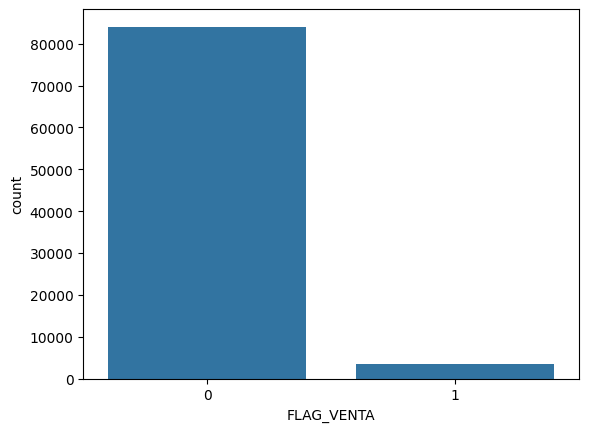

In [ ]:
sns.countplot(x='FLAG_VENTA', data=df)
plt.show()

**Hallazgo**

- Dataset desbalanceada, solo el 3.99% acepta la renovacion de prestamo.
- Se deben de aplicar tecnicas de balanceo para no tener problemas a la hora de entrenar el modelo.
- Se debera utilizar ROC-AUC o Gini

Cuando la clase de interés es minoritaria, la accuracy puede ser engañosa porque un modelo puede lograr una alta precisión prediciendo la clase mayoritaria. Métricas como ROC-AUC o Gini son superiores porque evalúan la capacidad del modelo para diferenciar entre las clases en todos los posibles puntos de corte, proporcionando una visión más real y robusta del rendimiento predictivo, especialmente para la clase minoritaria que suele ser la de mayor interés de negocio.

In [ ]:
#Tipo de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87556 entries, 0 to 87555
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MES               87556 non-null  int64  
 1   CLIENTE           87556 non-null  int64  
 2   Linea_Renovado    87556 non-null  int64  
 3   Plazo_Renovado    87556 non-null  int64  
 4   FLAG_VENTA        87556 non-null  int64  
 5   Uso_Linea         68364 non-null  float64
 6   Uso_TrimLinea     68364 non-null  float64
 7   Nro_Entidades     87556 non-null  int64  
 8   Dif_Entidades     87556 non-null  int64  
 9   Saldo_Consumo     82370 non-null  float64
 10  Meses_oferta      73700 non-null  float64
 11  Ahorro            87556 non-null  int64  
 12  Prestamo_vigente  87556 non-null  int64  
 13  Promed_6Mdeuda    87556 non-null  float64
 14  EDAD              87555 non-null  float64
 15  SEXO              87555 non-null  object 
 16  EST_CIVIL         87555 non-null  object

**Hallazgo**:
- De las 22 variables, 3 son de texto o categoricas (object) y 19 son numericas
- De las 22 variables, 10 cuenta con valores nulos

In [ ]:
#Resumen estadistico
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
MES,87556.0,201504.906311,2.532233,201501.0,201503.000000,201505.000000,201507.000000,2.015090e+05
CLIENTE,87556.0,43778.500000,25275.384422,1.0,21889.750000,43778.500000,65667.250000,8.755600e+04
Linea_Renovado,87556.0,20938.425511,19528.059348,700.0,9100.000000,14300.000000,25350.000000,1.000000e+05
Plazo_Renovado,87556.0,32.364327,10.976920,6.0,24.000000,36.000000,36.000000,6.000000e+01
FLAG_VENTA,87556.0,0.039883,0.195686,0.0,0.000000,0.000000,0.000000,1.000000e+00
Uso_Linea,68364.0,0.128593,0.192200,0.0,0.000000,0.030634,0.191262,1.466976e+00
Uso_TrimLinea,68364.0,0.096935,0.204709,0.0,0.000000,0.000000,0.069125,1.666666e+00
Nro_Entidades,87556.0,1.906049,1.185088,0.0,1.000000,2.000000,3.000000,9.000000e+00
Dif_Entidades,87556.0,-0.112328,0.977435,-5.0,-1.000000,0.000000,0.000000,5.000000e+00
Saldo_Consumo,82370.0,14385.172299,21570.062428,0.0,4102.655000,8368.145000,15786.390000,7.227811e+05


,Nulo,Porcentaje Nulo
Uso_Linea,19192,21.919686
Uso_TrimLinea,19192,21.919686
Meses_oferta,13856,15.825300
Saldo_Consumo,5186,5.923066
SUELDO_ESTIMADO,37,0.042259
REGION,18,0.020558
EST_CIVIL,1,0.001142
EDAD,1,0.001142
SEXO,1,0.001142
ANTIGUEDAD_MES,1,0.001142


<Axes: >

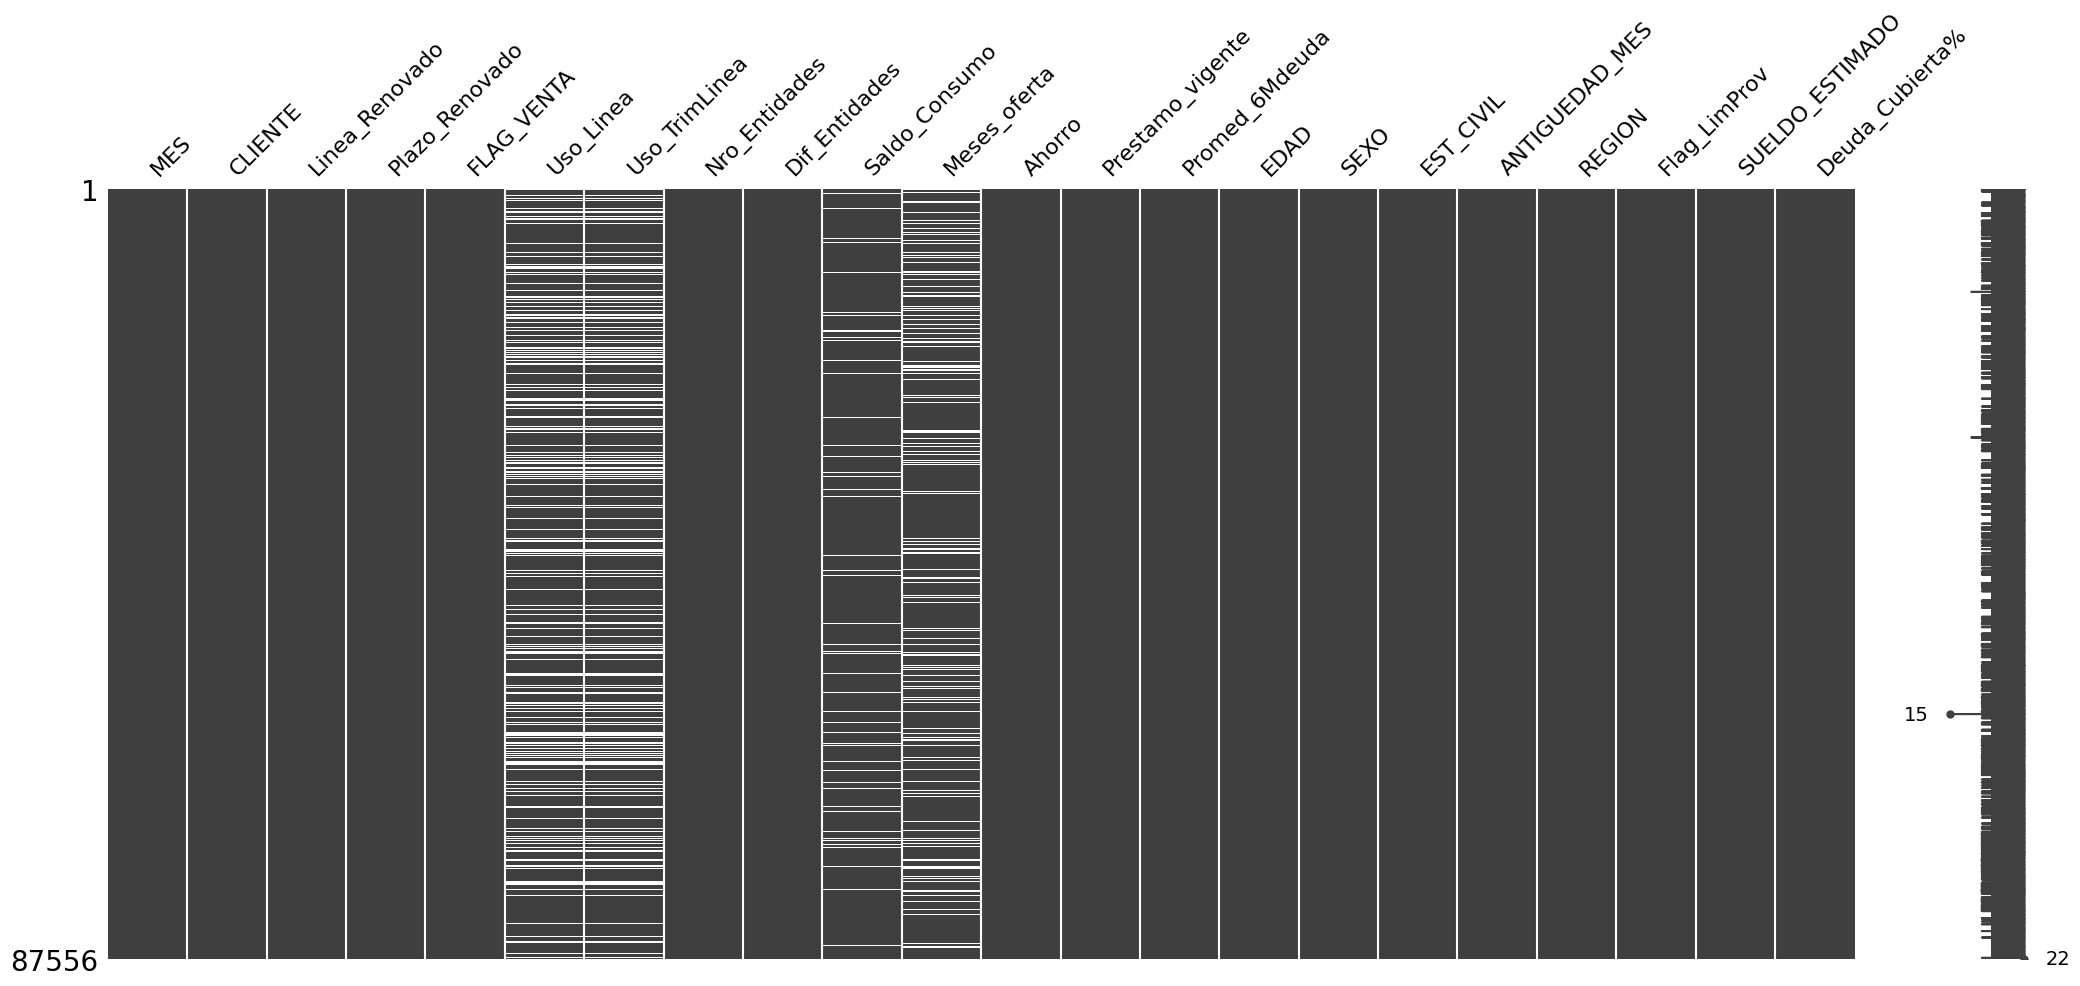

In [ ]:
#Nulos y duplicados
null_counts = df.isna().sum()
null_percentages = (df.isna().sum() / len(df)) * 100

null_info = pd.DataFrame({'Nulo': null_counts, 'Porcentaje Nulo': null_percentages})
null_info = null_info.sort_values(by='Nulo', ascending=False)
display(null_info.head(22))
msno.matrix(df)

In [ ]:
df.duplicated().sum()

np.int64(0)

**Hallazgo**


*   Se encontraron en el dataset 10 variables con valores nulos.
*   3 variables con un porcentaje >15% de valores nulos : Imputacion avanzada.
*   7 variables con un porcentaje <15% de valores nulos : Imputacion (mediana, promedio) o si eliminacion.  
*   No se detectan datos duplicados



In [ ]:
# Frecuencia de los meses
df['MES'].value_counts().head(10)


,count
MES,
201504,11191
201503,10853
201505,10602
201502,9532
201501,9313
201509,9215
201506,9020
201508,9002
201507,8828


# **4) Limpieza y Preparación de Datos**

**Hallazgo**


*   Al tener una Variable Target desbalanceada pronunciado (4%), no es recomendable eliminación de registros.




# *Tratamiento de variables 1*

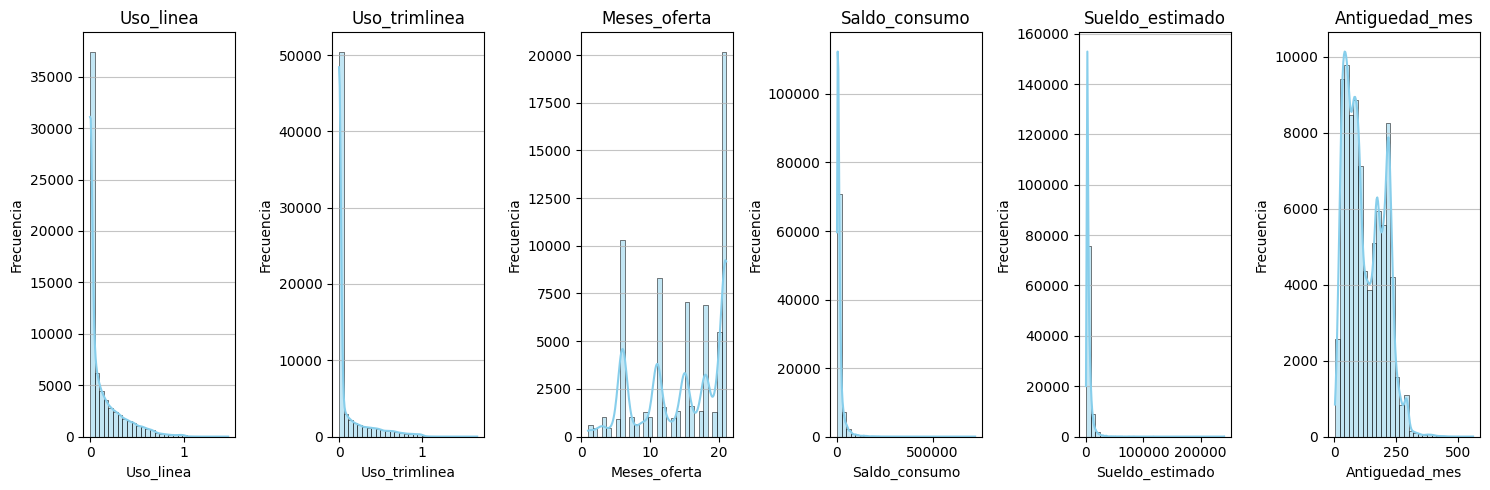

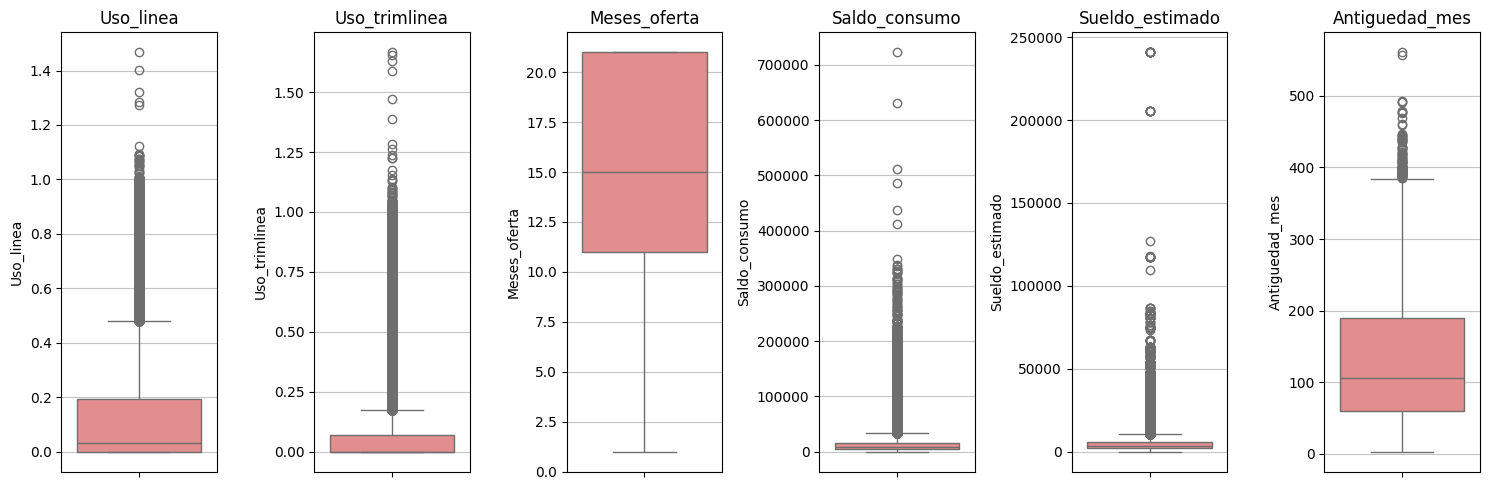

In [ ]:
#Histograma y bloxpots, para ver la distribucion y para identificar outliers.
num_cols_to_plot = ['Uso_Linea', 'Uso_TrimLinea', 'Meses_oferta','Saldo_Consumo','SUELDO_ESTIMADO','ANTIGUEDAD_MES']

# --- Histograms in a single row ---
plt.figure(figsize=(15, 5)) # Ajusta el tamaño de la figura para todos los histogramas
for i, col in enumerate(num_cols_to_plot):
    plt.subplot(1, len(num_cols_to_plot), i + 1) # 1 fila, N columnas, posición i+1
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'{col.capitalize()}')
    plt.xlabel(col.capitalize())
    plt.ylabel('Frecuencia')
    plt.grid(axis='y', alpha=0.75)
plt.tight_layout() # Ajusta el layout para evitar solapamientos
plt.show()

# --- Boxplots in a single row ---
plt.figure(figsize=(15, 5)) # Ajusta el tamaño de la figura para todos los boxplots
for i, col in enumerate(num_cols_to_plot):
    plt.subplot(1, len(num_cols_to_plot), i + 1) # 1 fila, N columnas, posición i+1
    sns.boxplot(y=df[col], color='lightcoral')
    plt.title(f'{col.capitalize()}')
    plt.ylabel(col.capitalize())
    plt.grid(axis='y', alpha=0.75)

plt.tight_layout() # Ajusta el layout para evitar solapamientos
plt.show()

**Hallazgos**

- Las variables Uso_Linea, Uso_trimlinea, Saldo_consumo, Sueldo_estimado y Antiguedad_mes tienen el promedio mucho mayor a la mediana, la mayoria de datos se concentran a la izquierda pero existen valores altos que jalan el promedio hacia la derecha haciendo que sea mayor que la mediana (outliers).
- La variable Meses_Oferta tiene su promedio y mediana valores muy cercanos, lo que sugiere una distribucion simetria o que no tiene datos outliers. (Se confirma lo ultimo)


**Tratamiento de los Outliers**

In [ ]:
# Variables a transformar
variables_to_transform = [
    'Uso_Linea',
    'Uso_TrimLinea',
    'Saldo_Consumo',
    'SUELDO_ESTIMADO',
    'ANTIGUEDAD_MES'
]

for col_name in variables_to_transform:
    # Crear el nuevo nombre de la columna transformada
    new_col_name = f'{col_name}_LOG'

    # Aplicar transformación logarítmica (np.log1p para manejar ceros)
    # Asegurarse de que la columna original exista antes de transformar
    if col_name in df.columns:
        df[new_col_name] = np.log1p(df[col_name])

        print(f"Transformación y imputación completada para '{col_name}' en '{new_col_name}'.")

    else:
        print(f"La columna '{col_name}' no se encontró en el DataFrame. Omitiendo transformación.\n")

# Mostrar el resumen descriptivo solo de las nuevas columnas LOG
log_only_cols = []
for col_name in variables_to_transform:
    if col_name in df.columns: # Check if original column exists to ensure LOG column could have been created
        log_only_cols.append(f'{col_name}_LOG')

display(df[log_only_cols].describe())

Transformación y imputación completada para 'Uso_Linea' en 'Uso_Linea_LOG'.
Transformación y imputación completada para 'Uso_TrimLinea' en 'Uso_TrimLinea_LOG'.
Transformación y imputación completada para 'Saldo_Consumo' en 'Saldo_Consumo_LOG'.
Transformación y imputación completada para 'SUELDO_ESTIMADO' en 'SUELDO_ESTIMADO_LOG'.
Transformación y imputación completada para 'ANTIGUEDAD_MES' en 'ANTIGUEDAD_MES_LOG'.


,Uso_Linea_LOG,Uso_TrimLinea_LOG,Saldo_Consumo_LOG,SUELDO_ESTIMADO_LOG,ANTIGUEDAD_MES_LOG
count,68364.000000,68364.000000,82370.000000,87519.000000,87555.000000
mean,0.108617,0.078707,8.883730,8.123991,4.605966
std,0.151268,0.157056,1.459871,0.833586,0.730526
min,0.000000,0.000000,0.000000,0.000000,1.386294
25%,0.000000,0.000000,8.319633,7.689138,4.094345
50%,0.030174,0.000000,9.032307,8.064360,4.672829
75%,0.175013,0.066841,9.666967,8.630522,5.247024
max,0.902993,0.980829,13.490863,12.392179,6.331502


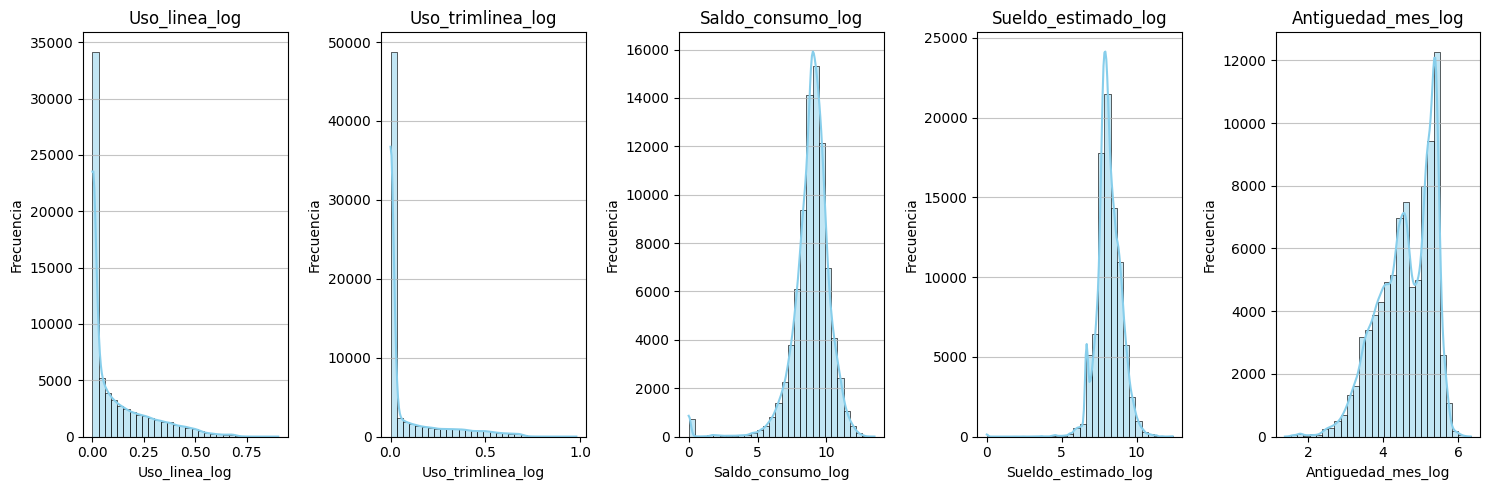

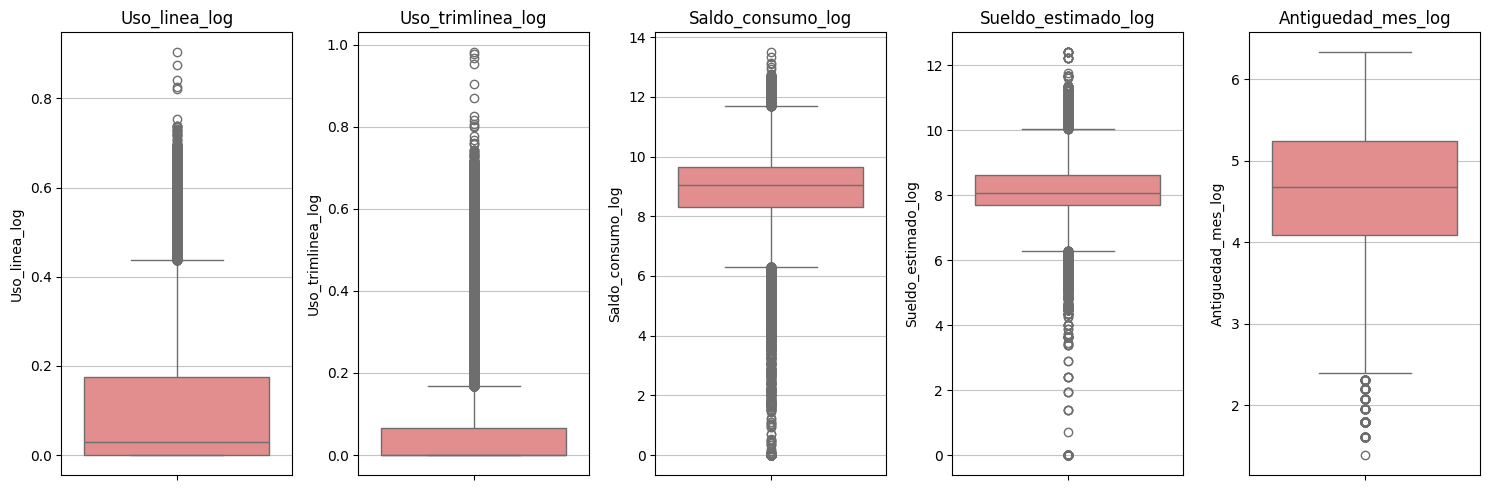

In [ ]:
#Histograma y bloxpots, para ver la distribucion y para identificar outliers.
num_cols_to_plot = ['Uso_Linea_LOG', 'Uso_TrimLinea_LOG','Saldo_Consumo_LOG','SUELDO_ESTIMADO_LOG','ANTIGUEDAD_MES_LOG']

# --- Histograms in a single row ---
plt.figure(figsize=(15, 5)) # Ajusta el tamaño de la figura para todos los histogramas
for i, col in enumerate(num_cols_to_plot):
    plt.subplot(1, len(num_cols_to_plot), i + 1) # 1 fila, N columnas, posición i+1
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'{col.capitalize()}')
    plt.xlabel(col.capitalize())
    plt.ylabel('Frecuencia')
    plt.grid(axis='y', alpha=0.75)
plt.tight_layout() # Ajusta el layout para evitar solapamientos
plt.show()

# --- Boxplots in a single row ---
plt.figure(figsize=(15, 5)) # Ajusta el tamaño de la figura para todos los boxplots
for i, col in enumerate(num_cols_to_plot):
    plt.subplot(1, len(num_cols_to_plot), i + 1) # 1 fila, N columnas, posición i+1
    sns.boxplot(y=df[col], color='lightcoral')
    plt.title(f'{col.capitalize()}')
    plt.ylabel(col.capitalize())
    plt.grid(axis='y', alpha=0.75)

plt.tight_layout() # Ajusta el layout para evitar solapamientos
plt.show()

# *Tratamiento de variables 2*

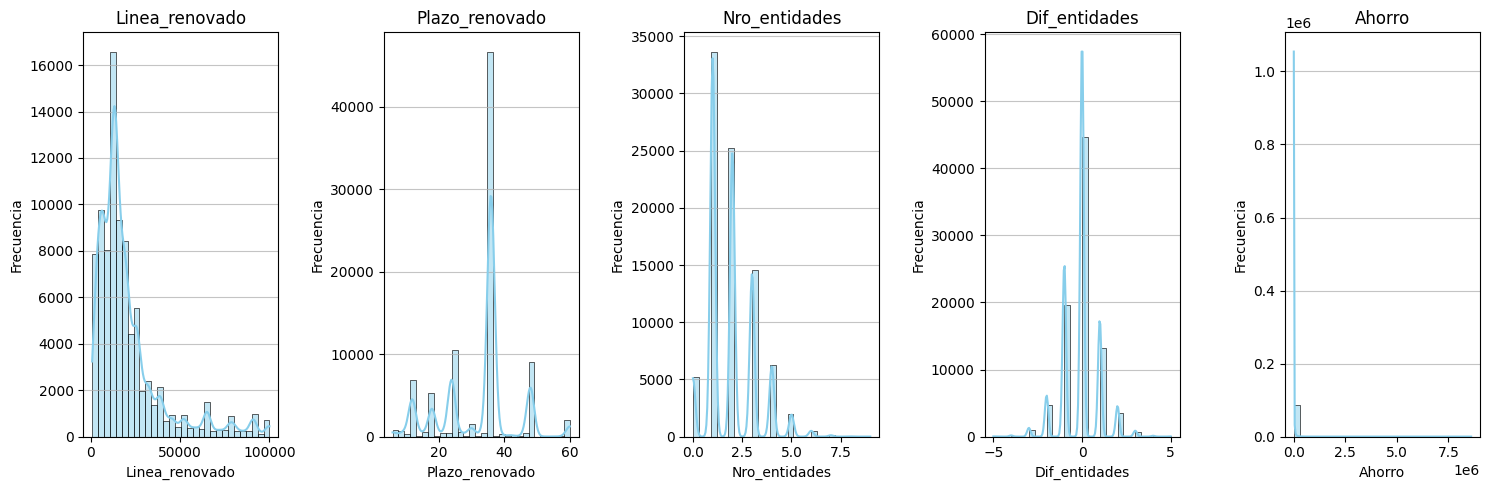

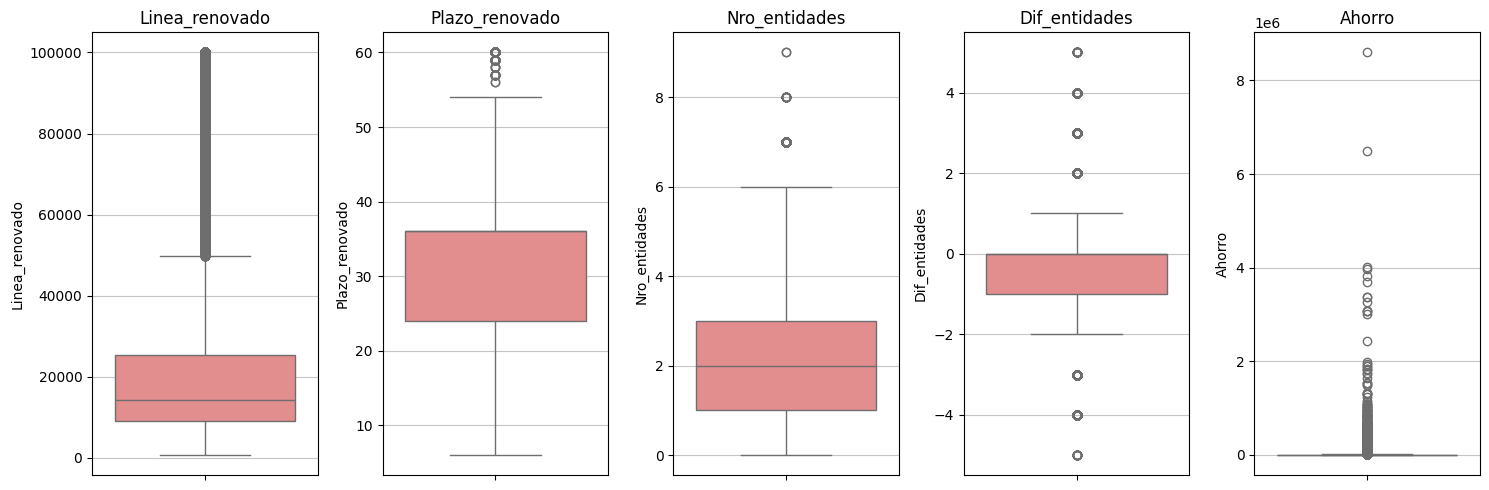

In [ ]:
#Histograma y bloxpots, para ver la distribucion y para identificar outliers.
num_cols_to_plot = ['Linea_Renovado', 'Plazo_Renovado', 'Nro_Entidades','Dif_Entidades','Ahorro']

# --- Histograms in a single row ---
plt.figure(figsize=(15, 5)) # Ajusta el tamaño de la figura para todos los histogramas
for i, col in enumerate(num_cols_to_plot):
    plt.subplot(1, len(num_cols_to_plot), i + 1) # 1 fila, N columnas, posición i+1
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'{col.capitalize()}')
    plt.xlabel(col.capitalize())
    plt.ylabel('Frecuencia')
    plt.grid(axis='y', alpha=0.75)
plt.tight_layout() # Ajusta el layout para evitar solapamientos
plt.show()

# --- Boxplots in a single row ---
plt.figure(figsize=(15, 5)) # Ajusta el tamaño de la figura para todos los boxplots
for i, col in enumerate(num_cols_to_plot):
    plt.subplot(1, len(num_cols_to_plot), i + 1) # 1 fila, N columnas, posición i+1
    sns.boxplot(y=df[col], color='lightcoral')
    plt.title(f'{col.capitalize()}')
    plt.ylabel(col.capitalize())
    plt.grid(axis='y', alpha=0.75)

plt.tight_layout() # Ajusta el layout para evitar solapamientos
plt.show()

**Hallazgos**

- Las variables Linea_renovado y Ahorro tienen el promedio mucho mayor a la mediana, la mayoria de datos se concentran a la izquierda pero existen valores altos que jalan el promedio hacia la derecha haciendo que sea mayor que la mediana (outliers).
- Las variable Plazo_renovado, Nro_entidades y Dif_entidades tienen un promedio y mediana cercana, aun con valores outliers, estos no jala el promedio. Significa que estan bien agrupados y estos datos outliers no interfieren en la distribucion.

**Tratamiento de los Outliers**

- La variable Ahorro tiene valores negativo (saldo negativo, deudas).
Usamos Capping (reemplazar los valores negativos por cero) para poder tratar los outliers con el logaritmo.

In [ ]:
# Reemplazar valores negativos en 'Ahorro' por 0
df['Ahorro'] = np.maximum(0, df['Ahorro'])

print("Valores negativos en 'Ahorro' reemplazados por 0.")
display(df[['Ahorro']].head())
display(df[['Ahorro']].describe())

Valores negativos en 'Ahorro' reemplazados por 0.


,Ahorro
0,1850
1,2093
2,16208
3,1531
4,308


,Ahorro
count,8.755600e+04
mean,1.080557e+04
std,7.068362e+04
min,0.000000e+00
25%,1.470000e+02
50%,1.208000e+03
75%,5.246000e+03
max,8.597760e+06


In [ ]:
# Variables a transformar
variables_to_transform = [
    'Linea_Renovado',
    'Ahorro'
]

for col_name in variables_to_transform:
    # Crear el nuevo nombre de la columna transformada
    new_col_name = f'{col_name}_LOG'

    # Aplicar transformación logarítmica (np.log1p para manejar ceros)
    # Asegurarse de que la columna original exista antes de transformar
    if col_name in df.columns:
        df[new_col_name] = np.log1p(df[col_name])

        print(f"Transformación y imputación completada para '{col_name}' en '{new_col_name}'.")

    else:
        print(f"La columna '{col_name}' no se encontró en el DataFrame. Omitiendo transformación.\n")

# Mostrar el resumen descriptivo solo de las nuevas columnas LOG
log_only_cols = []
for col_name in variables_to_transform:
    if col_name in df.columns: # Check if original column exists to ensure LOG column could have been created
        log_only_cols.append(f'{col_name}_LOG')

display(df[log_only_cols].describe())

Transformación y imputación completada para 'Linea_Renovado' en 'Linea_Renovado_LOG'.
Transformación y imputación completada para 'Ahorro' en 'Ahorro_LOG'.


,Linea_Renovado_LOG,Ahorro_LOG
count,87556.000000,87556.000000
mean,9.593202,6.350913
std,0.865912,3.246930
min,6.552508,0.000000
25%,9.116140,4.997212
50%,9.568085,7.097549
75%,10.140573,8.565412
max,11.512935,15.967012


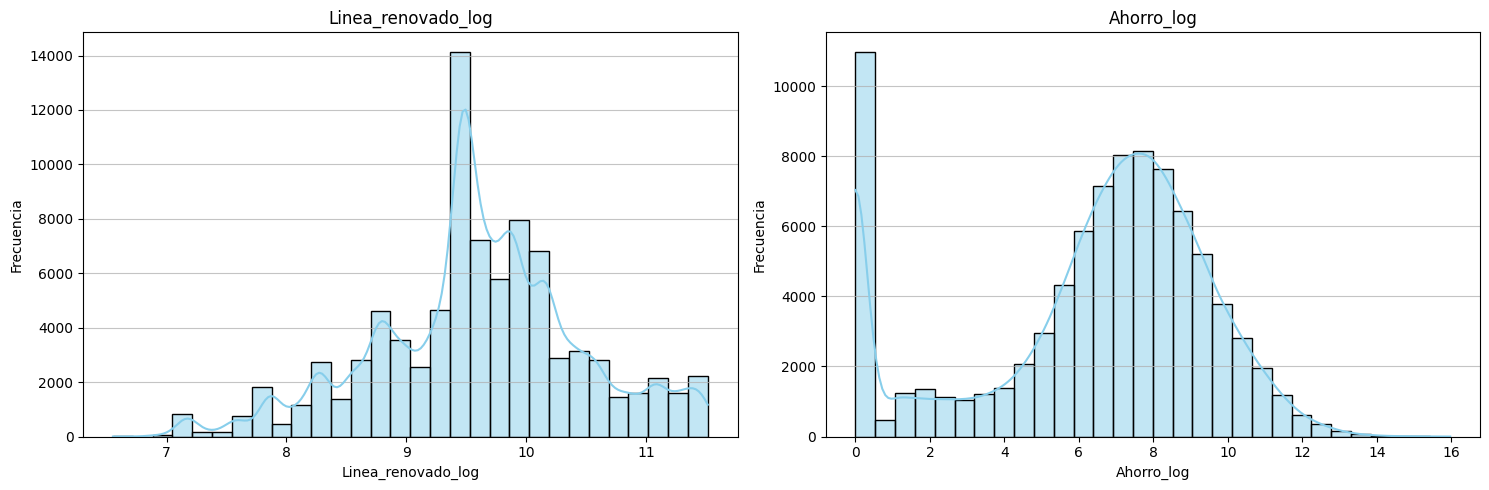

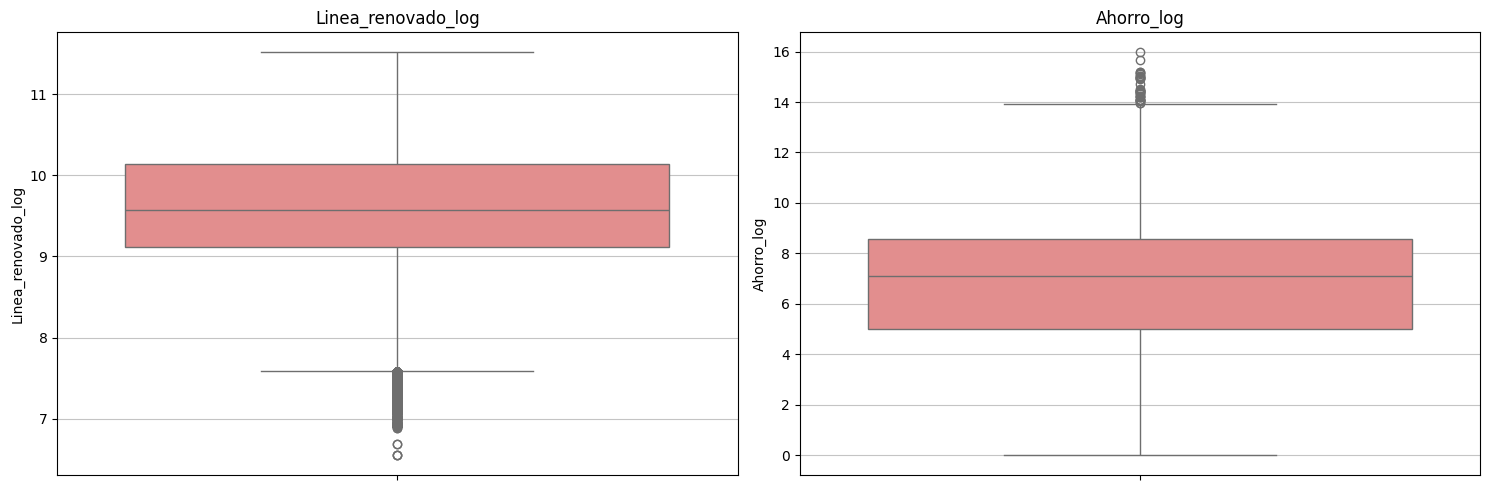

In [ ]:
#Histograma y bloxpots, para ver la distribucion y para identificar outliers.
num_cols_to_plot = ['Linea_Renovado_LOG', 'Ahorro_LOG']

# --- Histograms in a single row ---
plt.figure(figsize=(15, 5)) # Ajusta el tamaño de la figura para todos los histogramas
for i, col in enumerate(num_cols_to_plot):
    plt.subplot(1, len(num_cols_to_plot), i + 1) # 1 fila, N columnas, posición i+1
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'{col.capitalize()}')
    plt.xlabel(col.capitalize())
    plt.ylabel('Frecuencia')
    plt.grid(axis='y', alpha=0.75)
plt.tight_layout() # Ajusta el layout para evitar solapamientos
plt.show()

# --- Boxplots in a single row ---
plt.figure(figsize=(15, 5)) # Ajusta el tamaño de la figura para todos los boxplots
for i, col in enumerate(num_cols_to_plot):
    plt.subplot(1, len(num_cols_to_plot), i + 1) # 1 fila, N columnas, posición i+1
    sns.boxplot(y=df[col], color='lightcoral')
    plt.title(f'{col.capitalize()}')
    plt.ylabel(col.capitalize())
    plt.grid(axis='y', alpha=0.75)

plt.tight_layout() # Ajusta el layout para evitar solapamientos
plt.show()

# *Tratamiento de variables 3*

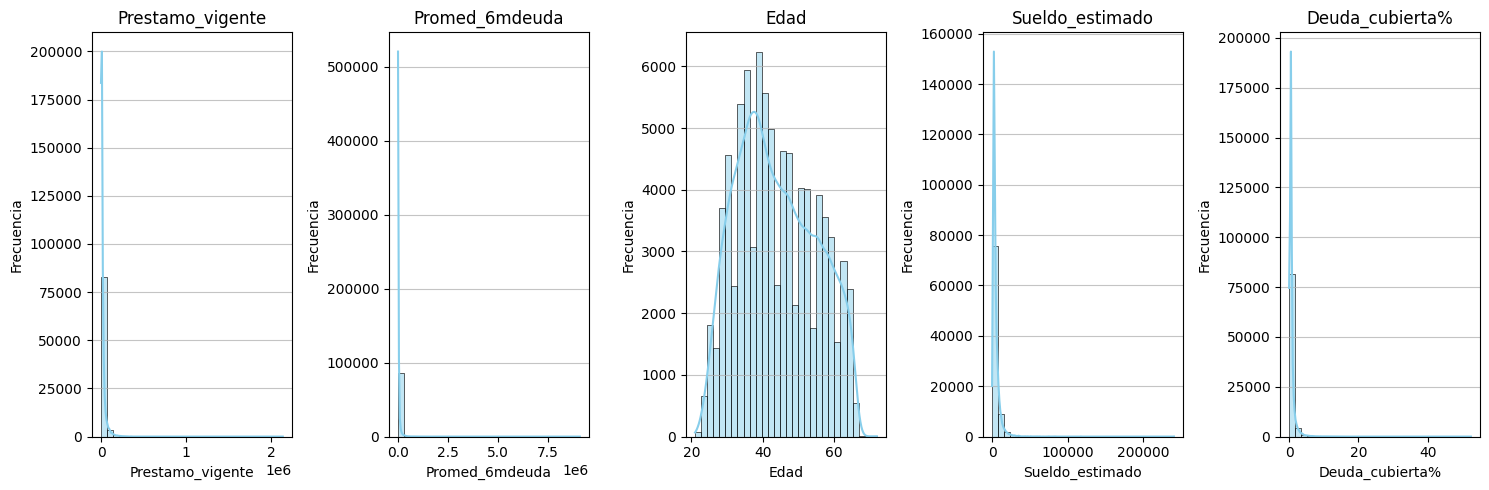

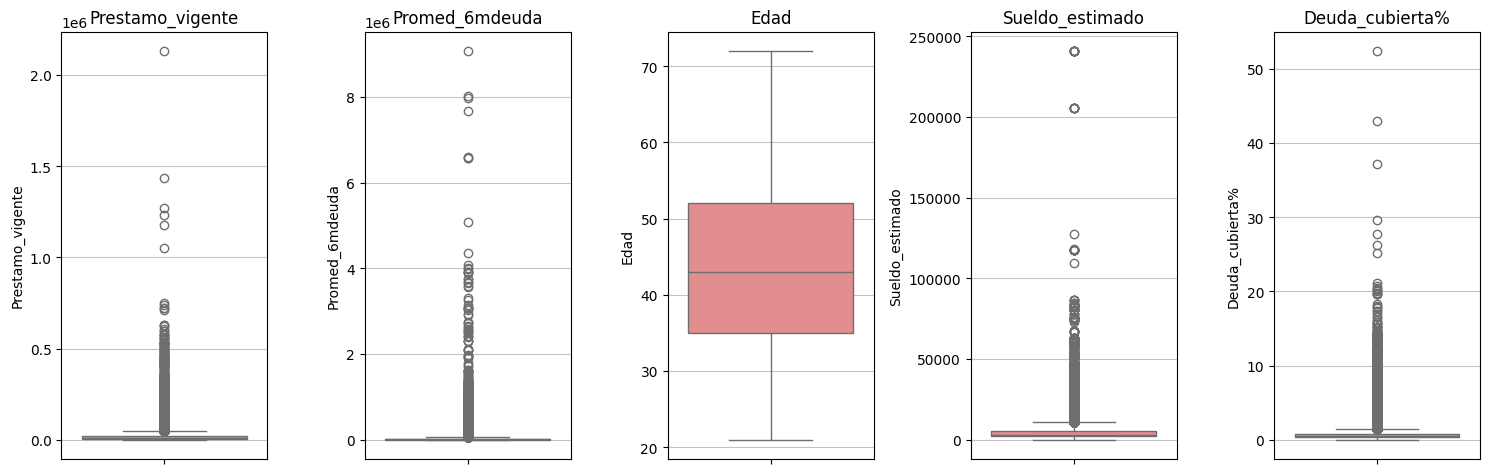

In [ ]:
#Histograma y bloxpots, para ver la distribucion y para identificar outliers.
num_cols_to_plot = ['Prestamo_vigente', 'Promed_6Mdeuda', 'EDAD','SUELDO_ESTIMADO','Deuda_Cubierta%']

# --- Histograms in a single row ---
plt.figure(figsize=(15, 5)) # Ajusta el tamaño de la figura para todos los histogramas
for i, col in enumerate(num_cols_to_plot):
    plt.subplot(1, len(num_cols_to_plot), i + 1) # 1 fila, N columnas, posición i+1
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'{col.capitalize()}')
    plt.xlabel(col.capitalize())
    plt.ylabel('Frecuencia')
    plt.grid(axis='y', alpha=0.75)
plt.tight_layout() # Ajusta el layout para evitar solapamientos
plt.show()

# --- Boxplots in a single row ---
plt.figure(figsize=(15, 5)) # Ajusta el tamaño de la figura para todos los boxplots
for i, col in enumerate(num_cols_to_plot):
    plt.subplot(1, len(num_cols_to_plot), i + 1) # 1 fila, N columnas, posición i+1
    sns.boxplot(y=df[col], color='lightcoral')
    plt.title(f'{col.capitalize()}')
    plt.ylabel(col.capitalize())
    plt.grid(axis='y', alpha=0.75)

plt.tight_layout() # Ajusta el layout para evitar solapamientos
plt.show()

**Hallazgos**

- Las variables Prestamo_vigente, Promed_6Mdeuda, Sueldo_estimado y Deuda_cubierta% tienen el promedio mucho mayor a la mediana, la mayoria de datos se concentran a la izquierda pero existen valores altos que jalan el promedio hacia la derecha haciendo que sea mayor que la mediana (outliers).
- La variable Edad tiene un promedio y mediana cercana, aun con valores outliers, estos no jala el promedio. Significa que estan bien agrupados y estos datos outliers no interfieren en la distribucion.

**Tratamiento de los Outliers**

- La variable Prestamo_vigente y Promd_6Mdeuda tienen valores negativos (saldo negativo, deudas).
Usamos Capping (reemplazar los valores negativos por cero) para poder tratar los outliers con el logaritmo.

In [ ]:
df['Prestamo_vigente'] = np.maximum(0, df['Prestamo_vigente'])
df['Promed_6Mdeuda'] = np.maximum(0, df['Promed_6Mdeuda'])

print("Valores negativos en 'Prestamo_vigente' y 'Promed_6Mdeuda' reemplazados por 0.")
display(df[['Prestamo_vigente','Promed_6Mdeuda']].head())
display(df[['Prestamo_vigente','Promed_6Mdeuda']].describe())

Valores negativos en 'Prestamo_vigente' y 'Promed_6Mdeuda' reemplazados por 0.


,Prestamo_vigente,Promed_6Mdeuda
0,457,3754.333333
1,11200,1581.333333
2,4778,10241.000000
3,0,5797.333333
4,1935,16755.333330


,Prestamo_vigente,Promed_6Mdeuda
count,8.755600e+04,8.755600e+04
mean,1.967329e+04,2.874610e+04
std,3.503195e+04,1.225501e+05
min,0.000000e+00,0.000000e+00
25%,3.954000e+03,1.002792e+03
50%,1.016200e+04,6.363167e+03
75%,2.145300e+04,2.371033e+04
max,2.132740e+06,9.077797e+06


In [ ]:
# Variables a transformar
variables_to_transform = [
    'Prestamo_vigente', 'Promed_6Mdeuda', 'SUELDO_ESTIMADO','Deuda_Cubierta%'
]

for col_name in variables_to_transform:
    # Crear el nuevo nombre de la columna transformada
    new_col_name = f'{col_name}_LOG'

    # Aplicar transformación logarítmica (np.log1p para manejar ceros)
    # Asegurarse de que la columna original exista antes de transformar
    if col_name in df.columns:
        df[new_col_name] = np.log1p(df[col_name])

        print(f"Transformación y imputación completada para '{col_name}' en '{new_col_name}'.")

    else:
        print(f"La columna '{col_name}' no se encontró en el DataFrame. Omitiendo transformación.\n")

# Mostrar el resumen descriptivo solo de las nuevas columnas LOG
log_only_cols = []
for col_name in variables_to_transform:
    if col_name in df.columns: # Check if original column exists to ensure LOG column could have been created
        log_only_cols.append(f'{col_name}_LOG')

display(df[log_only_cols].describe())

Transformación y imputación completada para 'Prestamo_vigente' en 'Prestamo_vigente_LOG'.
Transformación y imputación completada para 'Promed_6Mdeuda' en 'Promed_6Mdeuda_LOG'.
Transformación y imputación completada para 'SUELDO_ESTIMADO' en 'SUELDO_ESTIMADO_LOG'.
Transformación y imputación completada para 'Deuda_Cubierta%' en 'Deuda_Cubierta%_LOG'.


,Prestamo_vigente_LOG,Promed_6Mdeuda_LOG,SUELDO_ESTIMADO_LOG,Deuda_Cubierta%_LOG
count,87556.000000,87556.000000,87519.000000,87556.000000
mean,8.511739,8.051416,8.123991,0.474404
std,2.843402,3.017317,0.833586,0.346392
min,0.000000,0.000000,0.000000,0.000000
25%,8.282736,6.911540,7.689138,0.282512
50%,9.226509,8.758439,8.064360,0.437043
75%,9.973666,10.073708,8.630522,0.573837
max,14.572919,16.021342,12.392179,3.978451


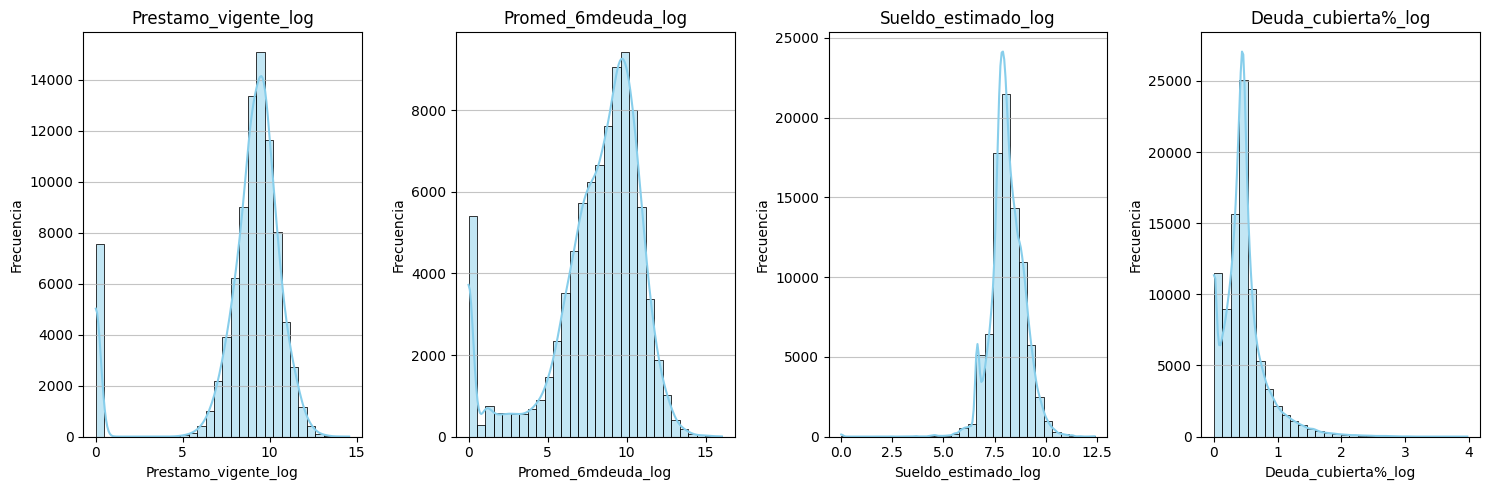

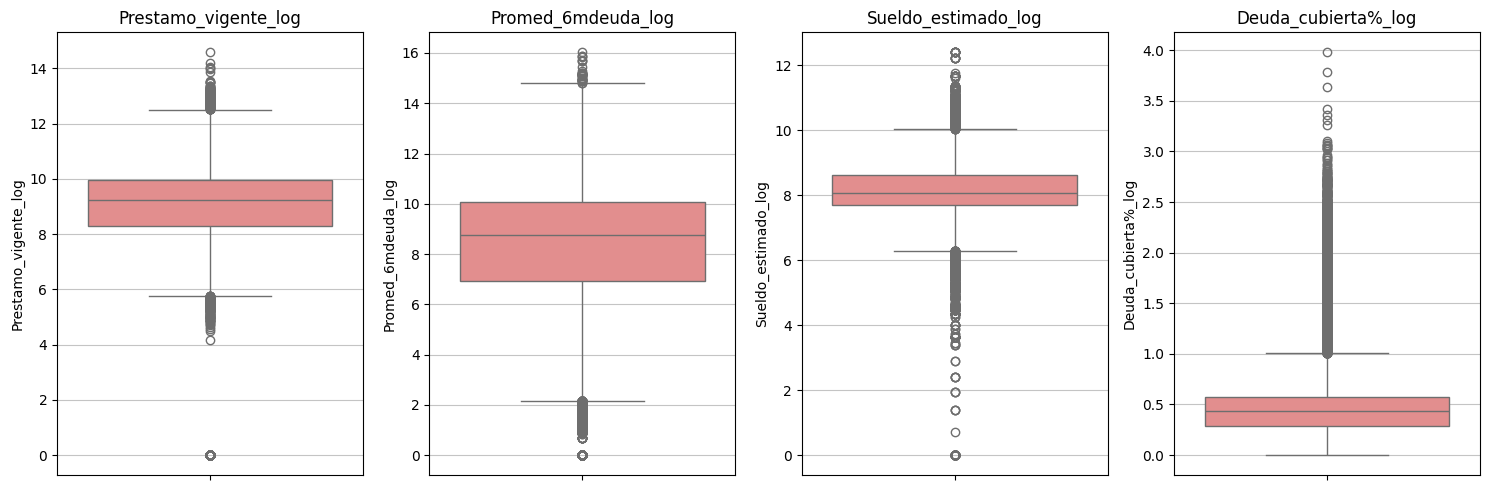

In [ ]:
#Histograma y bloxpots, para ver la distribucion y para identificar outliers.
num_cols_to_plot = ['Prestamo_vigente_LOG', 'Promed_6Mdeuda_LOG', 'SUELDO_ESTIMADO_LOG','Deuda_Cubierta%_LOG']

# --- Histograms in a single row ---
plt.figure(figsize=(15, 5)) # Ajusta el tamaño de la figura para todos los histogramas
for i, col in enumerate(num_cols_to_plot):
    plt.subplot(1, len(num_cols_to_plot), i + 1) # 1 fila, N columnas, posición i+1
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'{col.capitalize()}')
    plt.xlabel(col.capitalize())
    plt.ylabel('Frecuencia')
    plt.grid(axis='y', alpha=0.75)
plt.tight_layout() # Ajusta el layout para evitar solapamientos
plt.show()

# --- Boxplots in a single row ---
plt.figure(figsize=(15, 5)) # Ajusta el tamaño de la figura para todos los boxplots
for i, col in enumerate(num_cols_to_plot):
    plt.subplot(1, len(num_cols_to_plot), i + 1) # 1 fila, N columnas, posición i+1
    sns.boxplot(y=df[col], color='lightcoral')
    plt.title(f'{col.capitalize()}')
    plt.ylabel(col.capitalize())
    plt.grid(axis='y', alpha=0.75)

plt.tight_layout() # Ajusta el layout para evitar solapamientos
plt.show()

# **Tratamiento de Nulos**

In [ ]:
#Nulos y duplicados
null_counts = df.isna().sum()
null_percentages = (df.isna().sum() / len(df)) * 100

null_info = pd.DataFrame({'Nulo': null_counts, 'Porcentaje Nulo': null_percentages})
null_info = null_info.sort_values(by='Nulo', ascending=False)
display(null_info.head(33))

,Nulo,Porcentaje Nulo
Uso_TrimLinea,19192,21.919686
Uso_Linea,19192,21.919686
Uso_TrimLinea_LOG,19192,21.919686
Uso_Linea_LOG,19192,21.919686
Meses_oferta,13856,15.825300
Saldo_Consumo_LOG,5186,5.923066
Saldo_Consumo,5186,5.923066
SUELDO_ESTIMADO,37,0.042259
SUELDO_ESTIMADO_LOG,37,0.042259
REGION,18,0.020558


**Imputaciones**

# Uso_TrimLinea_LOG

21.92% de valores nulos, reemplazarlos con un IC

In [ ]:
# Calcula el promedio y la desviacion estandar para Uso_TrimLinea_LOG
mean_trim_log = df['Uso_TrimLinea_LOG'].mean()
std_trim_log = df['Uso_TrimLinea_LOG'].std()

lower_bound = mean_trim_log - std_trim_log
upper_bound = mean_trim_log + std_trim_log

# Identifico los nulos
null_indices = df['Uso_TrimLinea_LOG'].isnull()
num_nulls = null_indices.sum()

# Se genera una lista aleatoria con un tope maximo de el promedio + desviacion y
# un tope minimo de el promedio - desviacion.
random_imputed_values = np.random.uniform(max(0, lower_bound), upper_bound, num_nulls)

# Se rellena los nulos con la lista generada
df.loc[null_indices, 'Uso_TrimLinea_LOG'] = random_imputed_values

print(f"Imputación de 'Uso_TrimLinea_LOG' completada usando sampling aleatorio.")
print(f"Nulos restantes en 'Uso_TrimLinea_LOG': {df['Uso_TrimLinea_LOG'].isna().sum()}")

Imputación de 'Uso_TrimLinea_LOG' completada usando sampling aleatorio.
Nulos restantes en 'Uso_TrimLinea_LOG': 0


,Uso_TrimLinea_LOG
count,87556.000000
mean,0.087235
std,0.143292
min,0.000000
25%,0.000000
50%,0.000000
75%,0.133400
max,0.980829


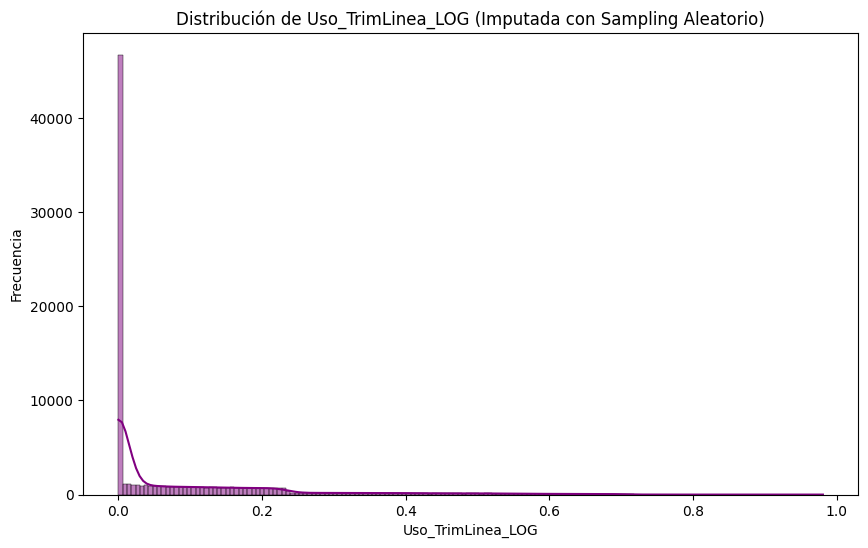

In [ ]:
# Display descriptive statistics to see the effect of imputation
display(df['Uso_TrimLinea_LOG'].describe())

# Visualizar la distribución de la variable después de la imputación
plt.figure(figsize=(10, 6))
sns.histplot(df['Uso_TrimLinea_LOG'], kde=True, color='purple')
plt.title('Distribución de Uso_TrimLinea_LOG (Imputada con Sampling Aleatorio)')
plt.xlabel('Uso_TrimLinea_LOG')
plt.ylabel('Frecuencia')
plt.show()

# Uso_Linea_LOG

21.92% de valores nulos, reemplazarlos con un IC

In [ ]:
# Calcula el promedio y la desviacion estandar para Uso_Linea_LOG
mean_linea_log = df['Uso_Linea_LOG'].mean()
std_linea_log = df['Uso_Linea_LOG'].std()

lower_bound_linea = mean_linea_log - std_linea_log
upper_bound_linea = mean_linea_log + std_linea_log

# Identifico los nulos
null_indices_linea = df['Uso_Linea_LOG'].isnull()
num_nulls_linea = null_indices_linea.sum()

# Se genera una lista aleatoria con un tope maximo de el promedio + desviacion y
# un tope minimo de el promedio - desviacion.
random_imputed_values_linea = np.random.uniform(max(0, lower_bound_linea), upper_bound_linea, num_nulls_linea)

# Se rellena los nulos con la lista generada
df.loc[null_indices_linea, 'Uso_Linea_LOG'] = random_imputed_values_linea

print(f"Imputación de 'Uso_Linea_LOG' completada usando sampling aleatorio.")
print(f"Nulos restantes en 'Uso_Linea_LOG': {df['Uso_Linea_LOG'].isna().sum()}")

Imputación de 'Uso_Linea_LOG' completada usando sampling aleatorio.
Nulos restantes en 'Uso_Linea_LOG': 0


,Uso_Linea_LOG
count,87556.000000
mean,0.113299
std,0.138461
min,0.000000
25%,0.000000
50%,0.060086
75%,0.184494
max,0.902993


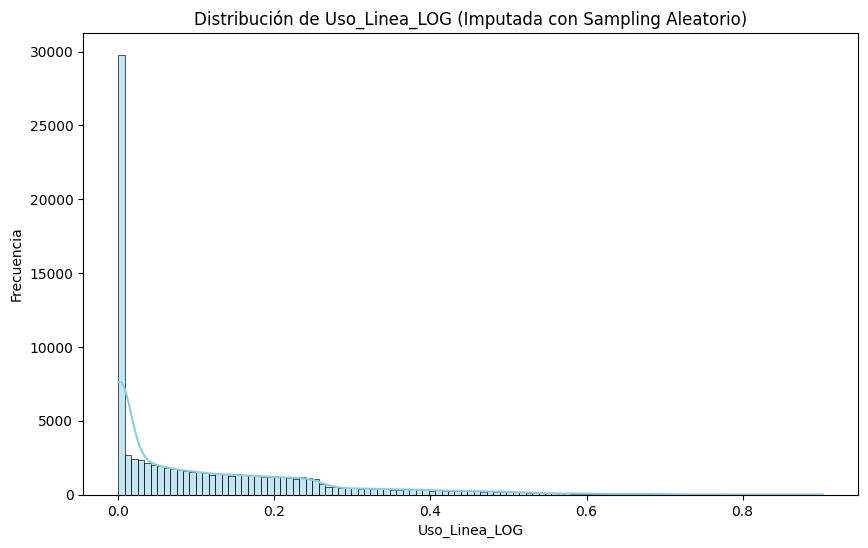

In [ ]:
# Display descriptive statistics to see the effect of imputation
display(df['Uso_Linea_LOG'].describe())

# Visualizar la distribución de la variable después de la imputación
plt.figure(figsize=(10, 6))
sns.histplot(df['Uso_Linea_LOG'], kde=True, color='skyblue')
plt.title('Distribución de Uso_Linea_LOG (Imputada con Sampling Aleatorio)')
plt.xlabel('Uso_Linea_LOG')
plt.ylabel('Frecuencia')
plt.show()

# Meses_oferta

15.83% de valores nulos, reemplazarlos con un IC

In [ ]:
# Calcula el promedio y la desviacion estandar para Uso_Linea_LOG
mean_linea_log = df['Meses_oferta'].mean()
std_linea_log = df['Meses_oferta'].std()

lower_bound_linea = mean_linea_log - std_linea_log
upper_bound_linea = mean_linea_log + std_linea_log

# Identifico los nulos
null_indices_linea = df['Meses_oferta'].isnull()
num_nulls_linea = null_indices_linea.sum()

# Se genera una lista aleatoria con un tope maximo de el promedio + desviacion y
# un tope minimo de el promedio - desviacion.
random_imputed_values_linea = np.random.uniform(max(0, lower_bound_linea), upper_bound_linea, num_nulls_linea)

# Se rellena los nulos con la lista generada
df.loc[null_indices_linea, 'Meses_oferta'] = random_imputed_values_linea

print(f"Imputación de 'Meses_oferta' completada usando sampling aleatorio.")
print(f"Nulos restantes en 'Meses_oferta': {df['Meses_oferta'].isna().sum()}")

Imputación de 'Meses_oferta' completada usando sampling aleatorio.
Nulos restantes en 'Meses_oferta': 0


,Meses_oferta
count,87556.000000
mean,14.702059
std,5.608344
min,1.000000
25%,11.000000
50%,15.000000
75%,20.000000
max,21.000000


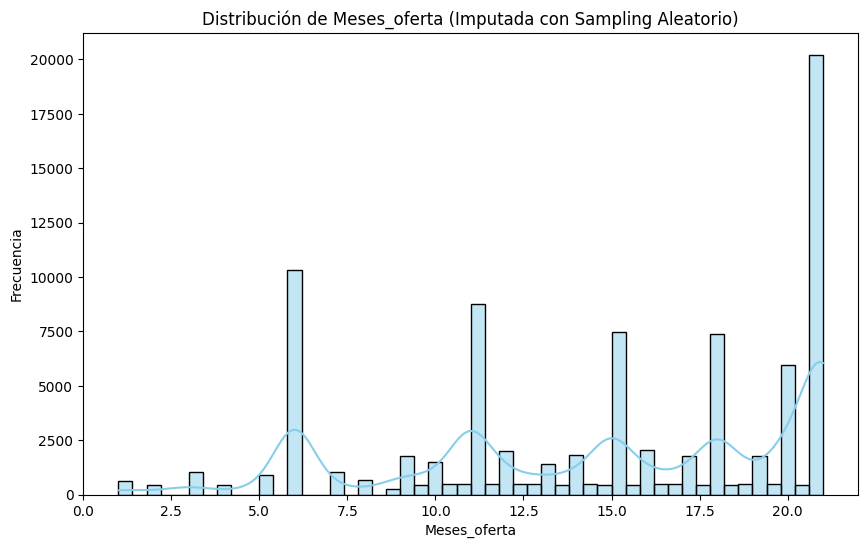

In [ ]:
# Display descriptive statistics to see the effect of imputation
display(df['Meses_oferta'].describe())

# Visualizar la distribución de la variable después de la imputación
plt.figure(figsize=(10, 6))
sns.histplot(df['Meses_oferta'], kde=True, color='skyblue')
plt.title('Distribución de Meses_oferta (Imputada con Sampling Aleatorio)')
plt.xlabel('Meses_oferta')
plt.ylabel('Frecuencia')
plt.show()

# Saldo_Consumo_LOG

5.9% de valores nulos, reemplazar los nulos con la mediana

Imputación de 'Saldo_Consumo_LOG' completada usando la mediana: 9.0323.
Nulos restantes en 'Saldo_Consumo_LOG': 0


,Saldo_Consumo_LOG
count,87556.000000
mean,8.892531
std,1.416410
min,0.000000
25%,8.380610
50%,9.032307
75%,9.626198
max,13.490863


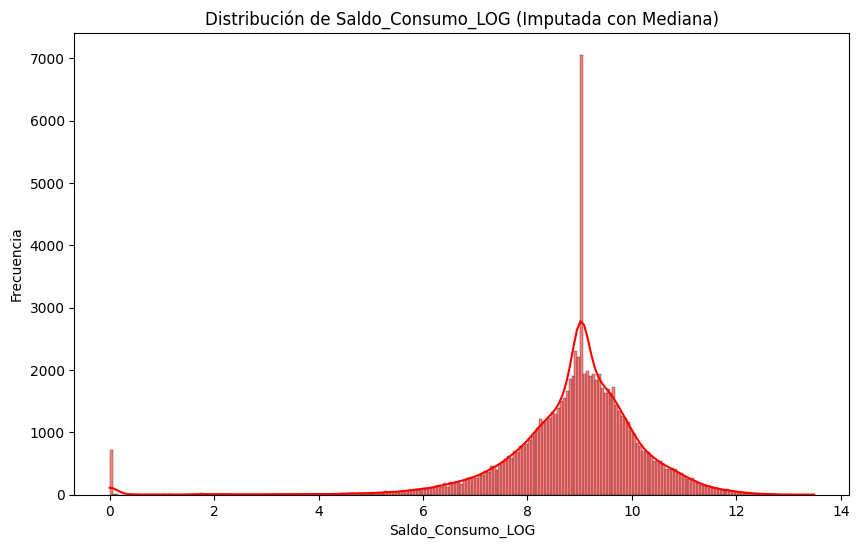

In [ ]:
# Calcular la mediana de 'Saldo_Consumo_LOG'
median_saldo_consumo_log = df['Saldo_Consumo_LOG'].median()

# Reemplazar los valores nulos en 'Saldo_Consumo_LOG' con la mediana
df['Saldo_Consumo_LOG'] = df['Saldo_Consumo_LOG'].fillna(median_saldo_consumo_log)

print(f"Imputación de 'Saldo_Consumo_LOG' completada usando la mediana: {median_saldo_consumo_log:.4f}.")
print(f"Nulos restantes en 'Saldo_Consumo_LOG': {df['Saldo_Consumo_LOG'].isna().sum()}")

# Display descriptive statistics to see the effect of imputation
display(df['Saldo_Consumo_LOG'].describe())

# Visualizar la distribución de la variable después de la imputación
plt.figure(figsize=(10, 6))
sns.histplot(df['Saldo_Consumo_LOG'], kde=True, color='red')
plt.title('Distribución de Saldo_Consumo_LOG (Imputada con Mediana)')
plt.xlabel('Saldo_Consumo_LOG')
plt.ylabel('Frecuencia')
plt.show()

# SUELDO_ESTIMADO_LOG
0.04% de valores nulos, reemplazar los nulos con la mediana

Imputación de 'SUELDO_ESTIMADO_LOG' completada usando la mediana: 8.0644.
Nulos restantes en 'SUELDO_ESTIMADO_LOG': 0


,SUELDO_ESTIMADO_LOG
count,87556.000000
mean,8.123966
std,0.833411
min,0.000000
25%,7.689371
50%,8.064360
75%,8.630522
max,12.392179


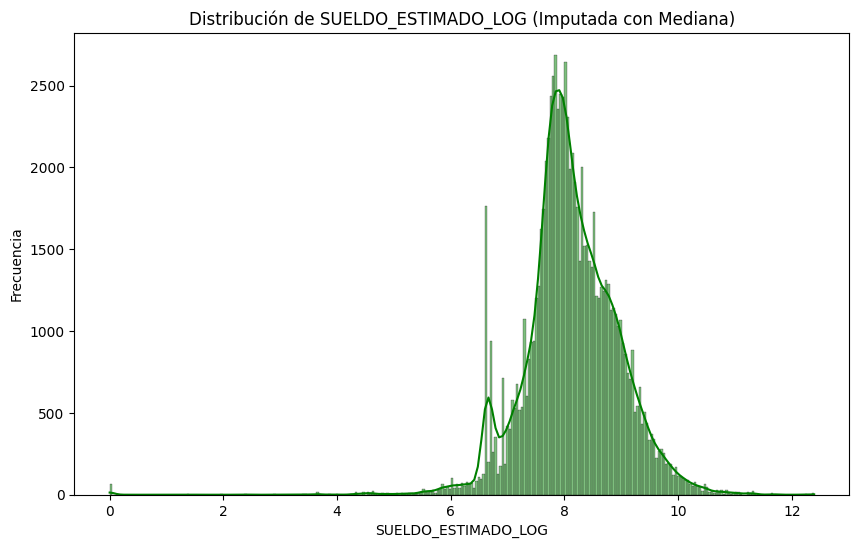

In [ ]:
# Calcular la mediana de 'SUELDO_ESTIMADO_LOG'
median_sueldo_log = df['SUELDO_ESTIMADO_LOG'].median()

# Reemplazar los valores nulos en 'SUELDO_ESTIMADO_LOG' con la mediana
df['SUELDO_ESTIMADO_LOG'] = df['SUELDO_ESTIMADO_LOG'].fillna(median_sueldo_log)

print(f"Imputación de 'SUELDO_ESTIMADO_LOG' completada usando la mediana: {median_sueldo_log:.4f}.")
print(f"Nulos restantes en 'SUELDO_ESTIMADO_LOG': {df['SUELDO_ESTIMADO_LOG'].isna().sum()}")

# Display descriptive statistics to see the effect of imputation
display(df['SUELDO_ESTIMADO_LOG'].describe())

# Visualizar la distribución de la variable después de la imputación
plt.figure(figsize=(10, 6))
sns.histplot(df['SUELDO_ESTIMADO_LOG'], kde=True, color='green')
plt.title('Distribución de SUELDO_ESTIMADO_LOG (Imputada con Mediana)')
plt.xlabel('SUELDO_ESTIMADO_LOG')
plt.ylabel('Frecuencia')
plt.show()

# ANTIGUEDAD_MES_LOG
0.0011% de valores nulos, reemplazar los nulos con la mediana

Imputación de 'ANTIGUEDAD_MES_LOG' completada usando la mediana: 4.6728.
Nulos restantes en 'ANTIGUEDAD_MES_LOG': 0


,ANTIGUEDAD_MES_LOG
count,87556.000000
mean,4.605967
std,0.730522
min,1.386294
25%,4.094345
50%,4.672829
75%,5.247024
max,6.331502


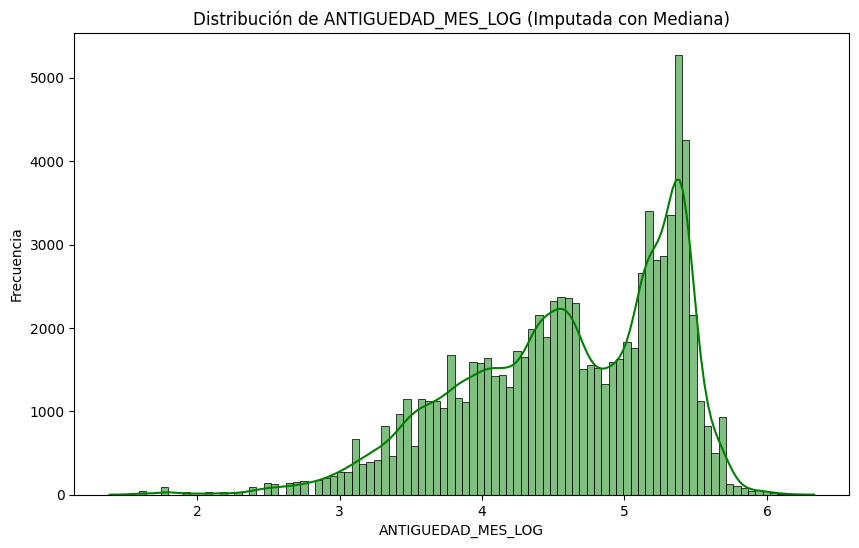

In [ ]:
# Calcular la mediana de 'ANTIGUEDAD_MES_LOG'
median_sueldo_log = df['ANTIGUEDAD_MES_LOG'].median()

# Reemplazar los valores nulos en 'ANTIGUEDAD_MES_LOG' con la mediana
df['ANTIGUEDAD_MES_LOG'] = df['ANTIGUEDAD_MES_LOG'].fillna(median_sueldo_log)

print(f"Imputación de 'ANTIGUEDAD_MES_LOG' completada usando la mediana: {median_sueldo_log:.4f}.")
print(f"Nulos restantes en 'ANTIGUEDAD_MES_LOG': {df['ANTIGUEDAD_MES_LOG'].isna().sum()}")

# Display descriptive statistics to see the effect of imputation
display(df['ANTIGUEDAD_MES_LOG'].describe())

# Visualizar la distribución de la variable después de la imputación
plt.figure(figsize=(10, 6))
sns.histplot(df['ANTIGUEDAD_MES_LOG'], kde=True, color='green')
plt.title('Distribución de ANTIGUEDAD_MES_LOG (Imputada con Mediana)')
plt.xlabel('ANTIGUEDAD_MES_LOG')
plt.ylabel('Frecuencia')
plt.show()

# EDAD
0.0011% de valores nulos, reemplazar los nulos con la mediana

Imputación de 'EDAD' completada usando la mediana: 43.0000.
Nulos restantes en 'EDAD': 0


,EDAD
count,87556.000000
mean,43.820743
std,10.822372
min,21.000000
25%,35.000000
50%,43.000000
75%,52.000000
max,72.000000


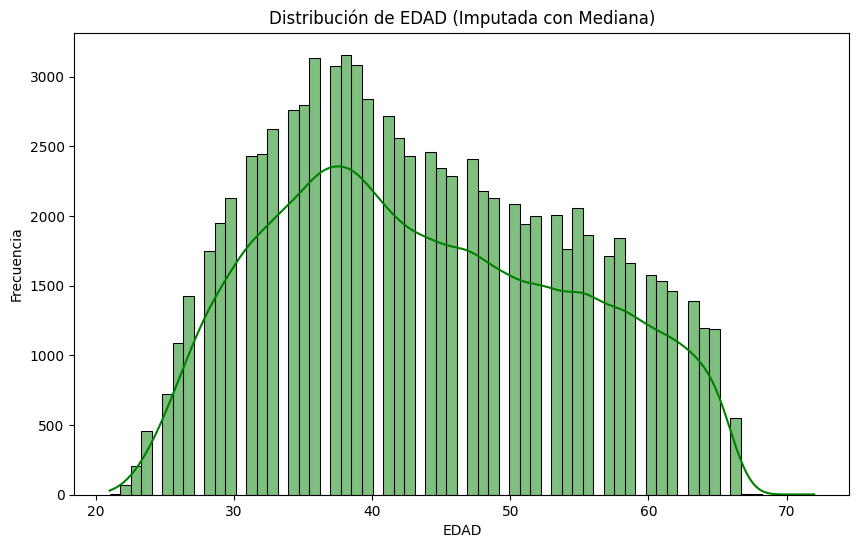

In [ ]:
# Calcular la mediana de 'EDAD'
median_sueldo_log = df['EDAD'].median()

# Reemplazar los valores nulos en 'EDAD' con la mediana
df['EDAD'] = df['EDAD'].fillna(median_sueldo_log)

print(f"Imputación de 'EDAD' completada usando la mediana: {median_sueldo_log:.4f}.")
print(f"Nulos restantes en 'EDAD': {df['EDAD'].isna().sum()}")

# Display descriptive statistics to see the effect of imputation
display(df['EDAD'].describe())

# Visualizar la distribución de la variable después de la imputación
plt.figure(figsize=(10, 6))
sns.histplot(df['EDAD'], kde=True, color='green')
plt.title('Distribución de EDAD (Imputada con Mediana)')
plt.xlabel('EDAD')
plt.ylabel('Frecuencia')
plt.show()

In [ ]:
columns_transformed_with_log = [
    'Uso_Linea', 'Uso_TrimLinea', 'Saldo_Consumo', 'SUELDO_ESTIMADO', 'ANTIGUEDAD_MES',
    'Linea_Renovado', 'Ahorro', 'Prestamo_vigente', 'Promed_6Mdeuda', 'Deuda_Cubierta%'
]

# Columns to be explicitly excluded from the null info display
columns_to_exclude_from_display = [
    'REGION', 'SEXO', 'EST_CIVIL'
]

# Combine all columns to exclude from the null_info DataFrame
all_columns_to_exclude = columns_transformed_with_log + columns_to_exclude_from_display

# Filter the null_info DataFrame to exclude these columns
filtered_null_info = null_info[~null_info.index.isin(all_columns_to_exclude)]

display(filtered_null_info.head(33))

,Nulo,Porcentaje Nulo
Uso_TrimLinea_LOG,19192,21.919686
Uso_Linea_LOG,19192,21.919686
Meses_oferta,13856,15.825300
Saldo_Consumo_LOG,5186,5.923066
SUELDO_ESTIMADO_LOG,37,0.042259
EDAD,1,0.001142
ANTIGUEDAD_MES_LOG,1,0.001142
MES,0,0.000000
Dif_Entidades,0,0.000000
Plazo_Renovado,0,0.000000


# **Análisis Bivariado de las variables cuantitativas**

<Axes: >

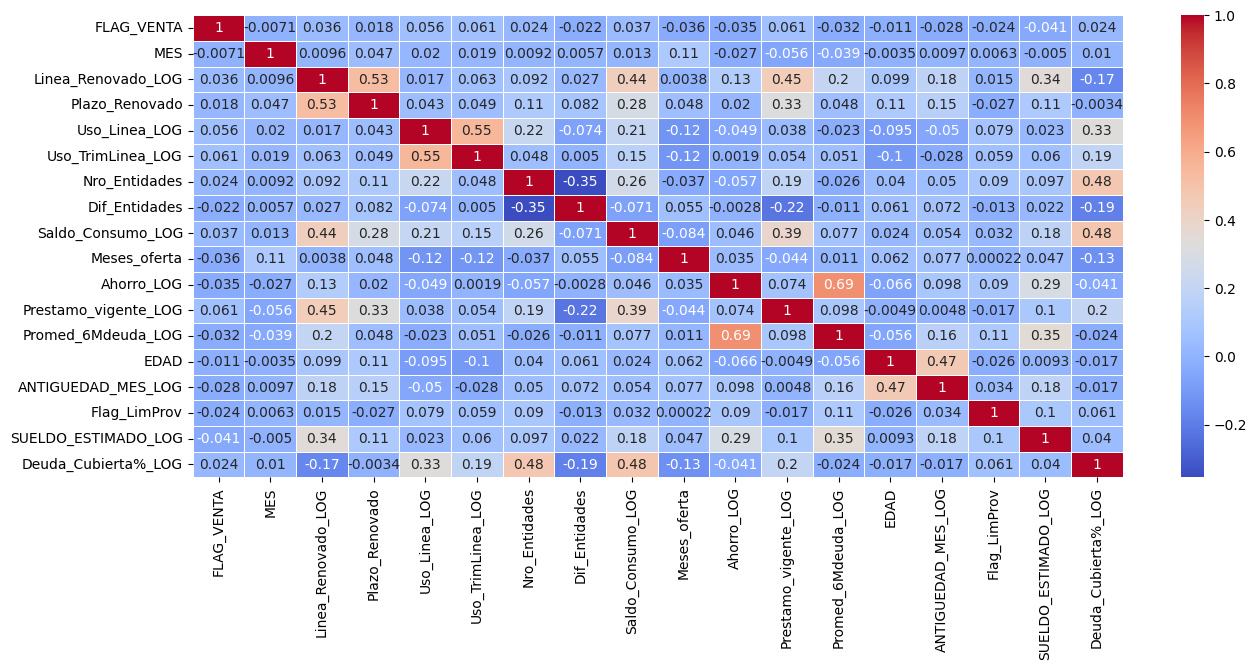

In [ ]:
#Análisis Bivariado : Correlación
corr = df[['FLAG_VENTA', 'MES','Linea_Renovado_LOG','Plazo_Renovado','Uso_Linea_LOG', 'Uso_TrimLinea_LOG','Nro_Entidades',
           'Dif_Entidades','Saldo_Consumo_LOG','Meses_oferta','Ahorro_LOG','Prestamo_vigente_LOG','Promed_6Mdeuda_LOG','EDAD',
           'ANTIGUEDAD_MES_LOG','Flag_LimProv','SUELDO_ESTIMADO_LOG','Deuda_Cubierta%_LOG']]
plt.figure(figsize=(15,6))
sns.heatmap(corr.corr(), annot=True, cmap='coolwarm', linewidths=0.5)

# **Análisis de variables cuantitativas**

In [ ]:
columns_for_correlation = [
    'MES', 'CLIENTE', 'Plazo_Renovado', 'Nro_Entidades', 'Dif_Entidades',
    'EDAD', 'Flag_LimProv', 'Meses_oferta', # Original columns without _LOG versions
    'Uso_Linea_LOG', 'Uso_TrimLinea_LOG', 'Saldo_Consumo_LOG',
    'SUELDO_ESTIMADO_LOG', 'ANTIGUEDAD_MES_LOG', 'Linea_Renovado_LOG',
    'Ahorro_LOG', 'Prestamo_vigente_LOG', 'Promed_6Mdeuda_LOG',
    'Deuda_Cubierta%_LOG' # All _LOG versions
]

# Eliminar cualquier columna que no exista en el dataframe actual (por si acaso)
columns_for_correlation = [col for col in columns_for_correlation if col in df.columns]

# Calcular la correlación de cada variable numérica con 'FLAG_VENTA'
correlations_transformed = df[columns_for_correlation + ['FLAG_VENTA']].corr()['FLAG_VENTA'].sort_values(ascending=False)

# Excluir la correlación de 'FLAG_VENTA' consigo misma
correlations_transformed = correlations_transformed.drop('FLAG_VENTA')

display(correlations_transformed.to_frame(name='Correlación con FLAG_VENTA (Transformada)'))

,Correlación con FLAG_VENTA (Transformada)
Uso_TrimLinea_LOG,0.061029
Prestamo_vigente_LOG,0.060719
Uso_Linea_LOG,0.056123
Saldo_Consumo_LOG,0.036605
Linea_Renovado_LOG,0.036277
Deuda_Cubierta%_LOG,0.024218
Nro_Entidades,0.023989
Plazo_Renovado,0.018120
CLIENTE,0.005785
MES,-0.007142


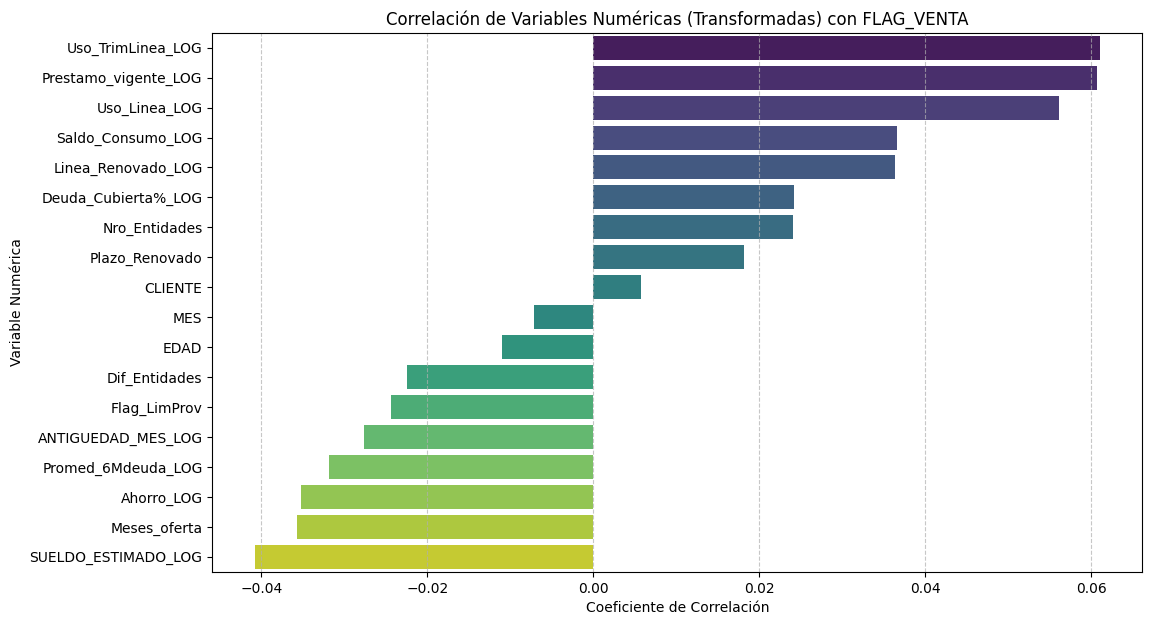

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x=correlations_transformed.values, y=correlations_transformed.index, hue=correlations_transformed.index, palette='viridis', legend=False)
plt.title('Correlación de Variables Numéricas (Transformadas) con FLAG_VENTA')
plt.xlabel('Coeficiente de Correlación')
plt.ylabel('Variable Numérica')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

**Hallazgo:**

Observamos que la variable target (FLAG_VENTA) tiene una correlación alta y positiva con:  

1.   Uso_TrimLinea_LOG (Uso de linea de credito constante)
2.   Prestamo_vigente_LOG (Familiarizado con manejo de deudas)
3.   Uso_Linea_LOG (Uso constante de su linea de credito)

Y una correlación negativa con:

1.   SUELDO_ESTIMADO_LOG (Mientras mas alto el sueldo del cliente, menos posibilidad de renovacion de prestamo / menos necesidad de financiacion externa)


# Análisis de Variables Categóricas

Existen 3
*   REGION
*   SEXO
*   EST_CIVIL

In [ ]:
variables_interes = ['REGION', 'SEXO', 'EST_CIVIL']

# Filtrar el DataFrame null_info para mostrar solo las variables de interés
nulls_categoricas = null_info[null_info.index.isin(variables_interes)]

# Mostrar el resultado
display(nulls_categoricas)

,Nulo,Porcentaje Nulo
REGION,18,0.020558
EST_CIVIL,1,0.001142
SEXO,1,0.001142


# **Imputación de nulos - variables categóricas**

## REGION

La variable 'REGION' es categórica y presenta un bajo porcentaje de valores nulos (0.02%). Para su imputación, utilizaremos la moda (el valor más frecuente y recomendada en variables categóricas).

Imputación de 'REGION' completada usando la moda: 'LIMA MODERNA'.
Nulos restantes en 'REGION': 0


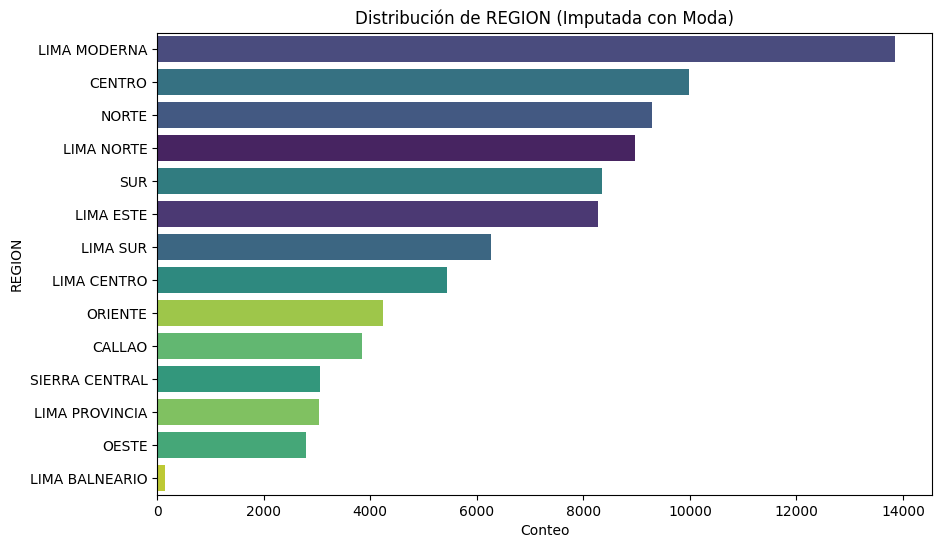

In [ ]:
# Calcular la moda de 'REGION'
mode_region = df['REGION'].mode()[0]

# Reemplazar los valores nulos en 'REGION' con la moda
df['REGION'] = df['REGION'].fillna(mode_region)

print(f"Imputación de 'REGION' completada usando la moda: '{mode_region}'.")
print(f"Nulos restantes en 'REGION': {df['REGION'].isna().sum()}")

# Verificar la distribución de 'REGION' después de la imputación
plt.figure(figsize=(10, 6))
sns.countplot(y=df['REGION'], order=df['REGION'].value_counts().index, palette='viridis', hue=df['REGION'], legend=False)
plt.title('Distribución de REGION (Imputada con Moda)')
plt.xlabel('Conteo')
plt.ylabel('REGION')
plt.show()

## Análisis Bivariado de 'REGION' vs 'FLAG_VENTA'

Despues de tratar los valores nulos, se explora la relación entre la variable categórica 'REGION' y nuestra variable target 'FLAG_VENTA' para encontrar la relacion de nuestro target 'FLAG_VENTA' entre las diferentes regiones.

In [ ]:
region_venta_proportion = df.groupby('REGION')['FLAG_VENTA'].value_counts(normalize=True).unstack().fillna(0)*100
display(region_venta_proportion.sort_values(by=1, ascending=False).style.format('{:.2f}%'))

FLAG_VENTA,0,1
REGION,,
ORIENTE,93.28%,6.72%
SIERRA CENTRAL,94.77%,5.23%
CENTRO,95.13%,4.87%
LIMA BALNEARIO,95.33%,4.67%
LIMA PROVINCIA,95.61%,4.39%
OESTE,95.70%,4.30%
SUR,95.88%,4.12%
LIMA ESTE,96.08%,3.92%
LIMA CENTRO,96.27%,3.73%


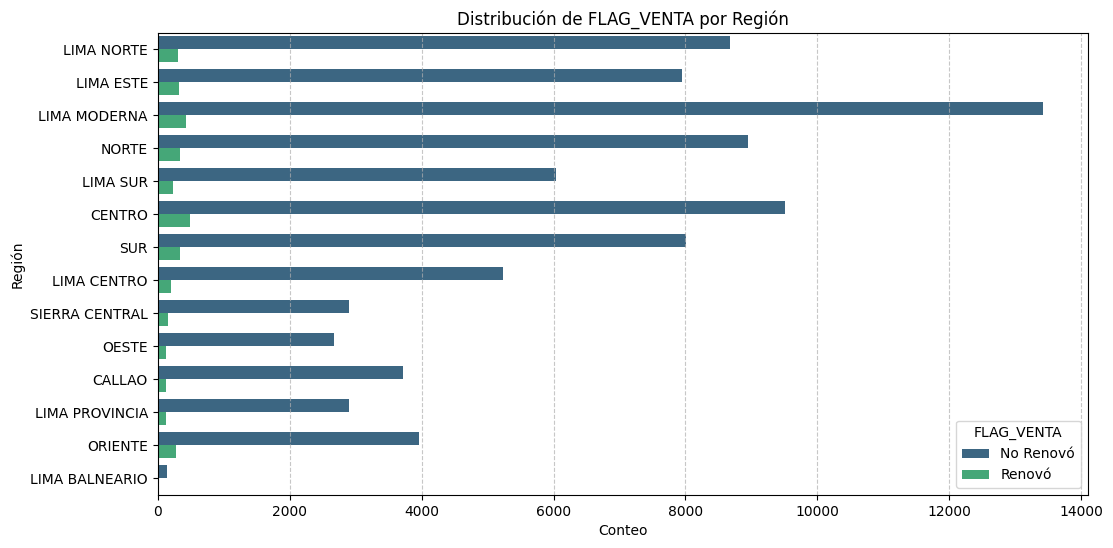

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='REGION', hue='FLAG_VENTA', palette='viridis')
plt.title('Distribución de FLAG_VENTA por Región')
plt.xlabel('Conteo')
plt.ylabel('Región')
plt.legend(title='FLAG_VENTA', labels=['No Renovó', 'Renovó'])
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

**Hallazgos:**


*   Las regiones con mayor probabilidad de renovacion (ORIENTE, SIERRA CENTRAL y CENTRO)
*  Las regiones con menor probabilidad de renovacion (CALLAO, LIMA NORTE y LIMA MODERNA)






## SEXO

La variable 'SEXO' es categórica y presenta un bajo porcentaje de valores nulos. Para su imputación, utilizaremos la moda (el valor más frecuente y recomendada en variables categóricas.).

Imputación de 'SEXO' completada usando la moda: 'M'.
Nulos restantes en 'SEXO': 0


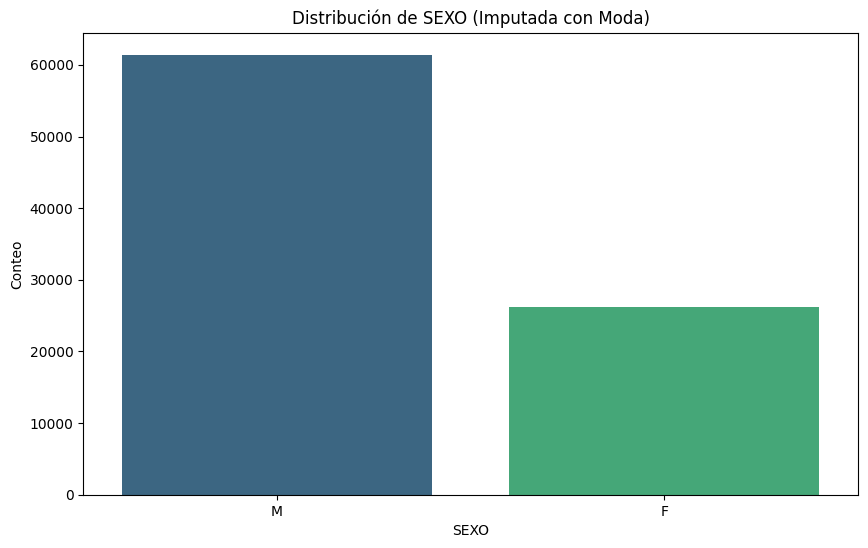

In [ ]:
# Calcular la moda de 'SEXO'
mode_sexo = df['SEXO'].mode()[0]

# Reemplazar los valores nulos en 'SEXO' con la moda
df['SEXO'] = df['SEXO'].fillna(mode_sexo)

print(f"Imputación de 'SEXO' completada usando la moda: '{mode_sexo}'.")
print(f"Nulos restantes en 'SEXO': {df['SEXO'].isna().sum()}")

# Verificar la distribución de 'SEXO' después de la imputación
plt.figure(figsize=(10, 6))
sns.countplot(x=df['SEXO'], order=df['SEXO'].value_counts().index, palette='viridis', hue=df['SEXO'], legend=False)
plt.title('Distribución de SEXO (Imputada con Moda)')
plt.xlabel('SEXO')
plt.ylabel('Conteo')
plt.show()

## Análisis Bivariado de 'SEXO' vs 'FLAG_VENTA'

Se explora la relación entre la variable categórica 'SEXO' y nuestra variable target 'FLAG_VENTA' para encontrar la relacion de nuestro target 'FLAG_VENTA' entre los diferentes géneros.


In [ ]:
sexo_venta_proportion = df.groupby('SEXO')['FLAG_VENTA'].value_counts(normalize=True).unstack().fillna(0)*100
display(sexo_venta_proportion.sort_values(by=1, ascending=False).style.format('{:.2f}%'))

FLAG_VENTA,0,1
SEXO,,
M,95.84%,4.16%
F,96.42%,3.58%


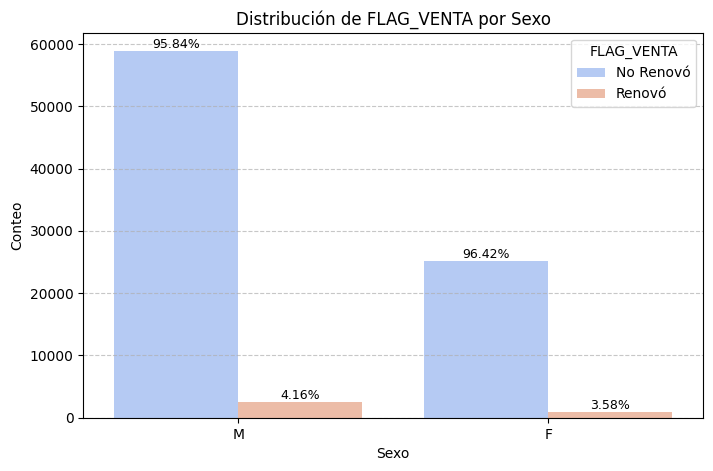

In [ ]:
# Determine the order of SEXO categories, typically by frequency or alphabetically
sex_order = df['SEXO'].value_counts().index.tolist() # Orders by frequency, a common default behavior for countplot

plt.figure(figsize=(8, 5))
# Pass the explicit order to sns.countplot to ensure consistency
ax = sns.countplot(data=df, x='SEXO', hue='FLAG_VENTA', palette='coolwarm', order=sex_order)
plt.title('Distribución de FLAG_VENTA por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Conteo')
plt.legend(title='FLAG_VENTA', labels=['No Renovó', 'Renovó'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Calculate proportions for annotations
sexo_proportions = df.groupby('SEXO')['FLAG_VENTA'].value_counts(normalize=True).unstack(fill_value=0) * 100

# Get the actual x-axis categories from the plot to ensure correct mapping
sex_categories_on_plot = [label.get_text() for label in ax.get_xticklabels()]

# Get the hue labels in the order they appear (typically 0 then 1)
hue_labels = sorted(df['FLAG_VENTA'].unique().tolist())

# Annotate bars with percentages
# Iterate through each container (each hue group)
for hue_group_idx, container in enumerate(ax.containers):
    # Get the current FLAG_VENTA value for this container
    current_flag_venta = hue_labels[hue_group_idx]

    # Iterate through each bar (patch) in the current hue group container
    for bar_idx, p in enumerate(container.patches):
        # Get the current SEXO category based on the bar's position within the container
        current_sex = sex_categories_on_plot[bar_idx]

        # Get the percentage from the pre-calculated proportions table
        percentage = sexo_proportions.loc[current_sex, current_flag_venta]

        # Add the text label above the bar
        ax.text(p.get_x() + p.get_width() / 2., # x-position (center of the bar)
                p.get_height(), # y-position (top of the bar)
                f'{percentage:.2f}%', # Text to display (e.g., '96.42%')
                ha='center', va='bottom', fontsize=9, color='black') # Alignment and style

plt.show()

**Hallazgos:**


*   Los hombres tienen una tasa de renovación ligeramente superior a la de las mujeres.

## EST_CIVIL

La variable 'EST_CIVIL' es categórica y presenta un bajo porcentaje de valores nulos. Para su imputación, utilizaremos la moda (el valor más frecuente y recomendada en variables categóricas).

Imputación de 'EST_CIVIL' completada usando la moda: 'S'.
Nulos restantes en 'EST_CIVIL': 0


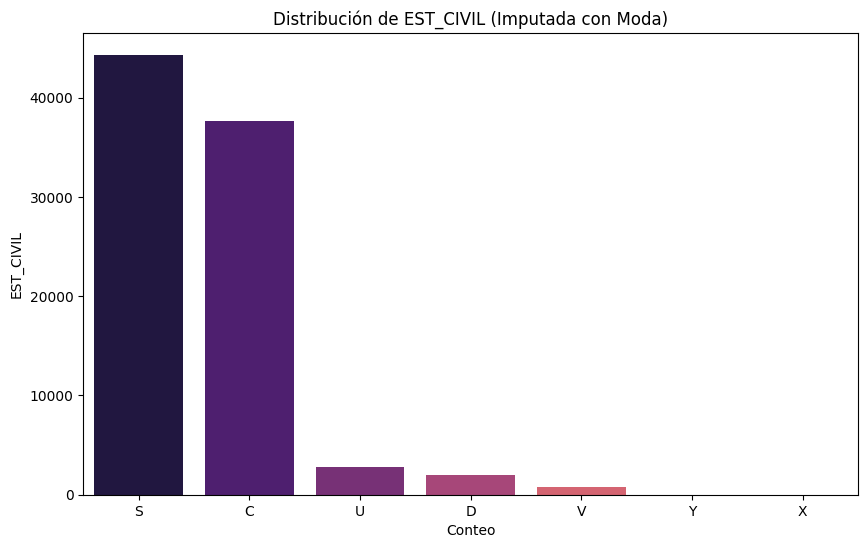

In [ ]:
# Calcular la moda de 'EST_CIVIL'
mode_est_civil = df['EST_CIVIL'].mode()[0]

# Reemplazar los valores nulos en 'EST_CIVIL' con la moda
df['EST_CIVIL'] = df['EST_CIVIL'].fillna(mode_est_civil)

print(f"Imputación de 'EST_CIVIL' completada usando la moda: '{mode_est_civil}'.")
print(f"Nulos restantes en 'EST_CIVIL': {df['EST_CIVIL'].isna().sum()}")

# Verificar la distribución de 'EST_CIVIL' después de la imputación
plt.figure(figsize=(10, 6))
sns.countplot(x='EST_CIVIL', data=df, hue='EST_CIVIL', palette='magma', legend=False)
plt.title('Distribución de EST_CIVIL (Imputada con Moda)')
plt.xlabel('Conteo')
plt.ylabel('EST_CIVIL')
plt.show()

## Análisis Bivariado de 'EST_CIVIL' vs 'FLAG_VENTA'

Ahora exploraremos la relación entre el 'EST_CIVIL' y nuestra variable target 'FLAG_VENTA' para ver si hay patrones en la renovación de préstamos basados en el estado civil.

In [ ]:
# Calcular las proporciones de FLAG_VENTA por EST_CIVIL, normalizado por el total del dataset
est_civil_total_proportion = df.groupby('EST_CIVIL')['FLAG_VENTA'].value_counts(normalize=True).unstack().fillna(0) * 100

# La normalización anterior se hace sobre el grupo. Para normalizar sobre el total:
est_civil_total_distribution = (df.groupby('EST_CIVIL')['FLAG_VENTA'].value_counts() / len(df) * 100).unstack().fillna(0)

display(est_civil_total_distribution.sort_values(by=1, ascending=False).style.format('{:.2f}%'))

FLAG_VENTA,0,1
EST_CIVIL,,
S,48.58%,2.07%
C,41.32%,1.65%
U,3.00%,0.14%
D,2.23%,0.10%
V,0.87%,0.03%
X,0.00%,0.00%
Y,0.01%,0.00%


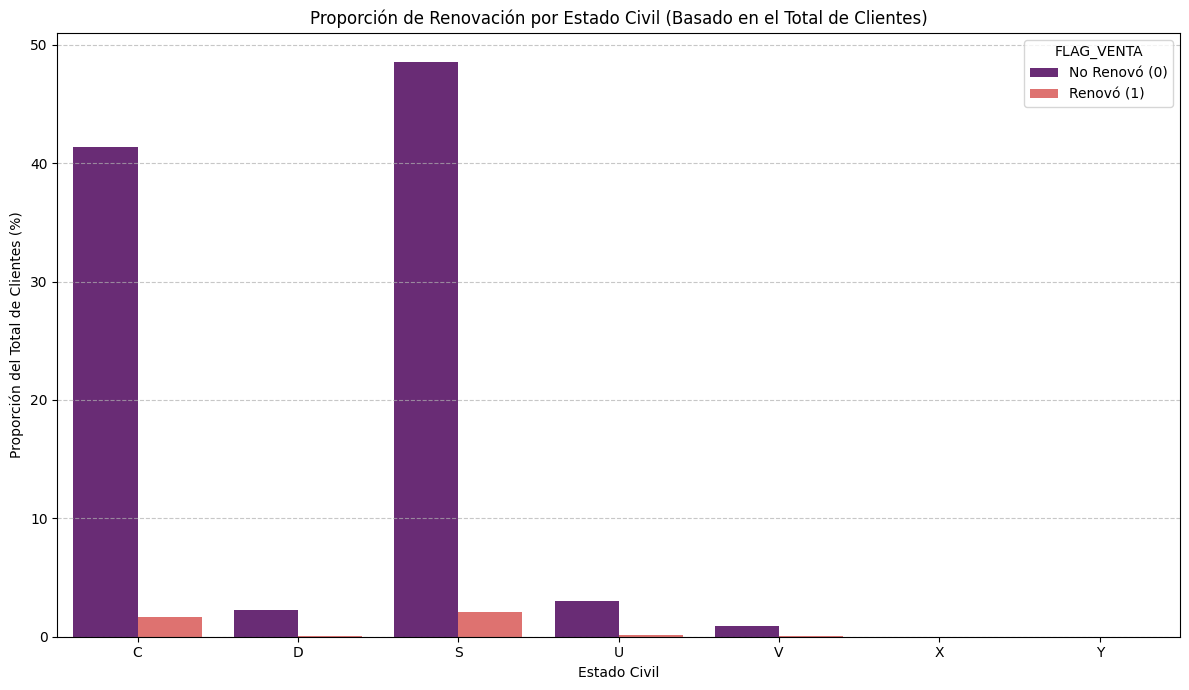

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convertir el DataFrame de proporciones a un formato largo para seaborn
plot_df = est_civil_total_distribution.reset_index().melt(id_vars='EST_CIVIL', var_name='FLAG_VENTA', value_name='Proporcion_Total')

# Filtrar las columnas que no sean numéricas de FLAG_VENTA si get_dummies las creó como bool
plot_df['FLAG_VENTA'] = plot_df['FLAG_VENTA'].astype(int)

plt.figure(figsize=(12, 7))
ax = sns.barplot(data=plot_df, x='EST_CIVIL', y='Proporcion_Total', hue='FLAG_VENTA', palette='magma', order=est_civil_total_distribution.index)
plt.title('Proporción de Renovación por Estado Civil (Basado en el Total de Clientes)')
plt.xlabel('Estado Civil')
plt.ylabel('Proporción del Total de Clientes (%)')

# Obtener los handles y labels del barplot para asegurar que los colores coincidan
handles, labels = ax.get_legend_handles_labels()
# Ajustar los labels de la leyenda
ax.legend(handles=handles, labels=['No Renovó (0)', 'Renovó (1)'], title='FLAG_VENTA')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Hallazgos**


*   Los estados civiles de Casado y Soltero representan la mayor parte de la base de clientes, tanto para lo que van a renovar como para los que no.




## **Preparación de Variables Categóricas (One-Hot Encoding)**

Convertiremos las variables categóricas 'REGION', 'SEXO' y 'EST_CIVIL' a un formato numérico utilizando One-Hot Encoding para que puedan ser utilizadas por los modelos de Machine Learning.

In [ ]:
# Identificar las columnas categóricas
categorical_cols = ['REGION', 'SEXO', 'EST_CIVIL']

# Aplicar One-Hot Encoding con dtype=int para obtener 0 y 1
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=False, dtype=int)

print(f"DataFrame original tenía {df.shape[1]} columnas.")
print(f"DataFrame después de One-Hot Encoding tiene {df_encoded.shape[1]} columnas.")

# Filtrar y mostrar solo las columnas one-hot encoded para las categorías especificadas
encoded_columns_to_show = [col for col in df_encoded.columns if col.startswith(('REGION_', 'SEXO_', 'EST_CIVIL_'))]
display(df_encoded[encoded_columns_to_show].head())

DataFrame original tenía 32 columnas.
DataFrame después de One-Hot Encoding tiene 52 columnas.


,REGION_CALLAO,REGION_CENTRO,REGION_LIMA BALNEARIO,REGION_LIMA CENTRO,REGION_LIMA ESTE,REGION_LIMA MODERNA,REGION_LIMA NORTE,REGION_LIMA PROVINCIA,REGION_LIMA SUR,REGION_NORTE,...,REGION_SUR,SEXO_F,SEXO_M,EST_CIVIL_C,EST_CIVIL_D,EST_CIVIL_S,EST_CIVIL_U,EST_CIVIL_V,EST_CIVIL_X,EST_CIVIL_Y
0,0,0,0,0,0,0,1,0,0,0,...,0,0,1,0,0,1,0,0,0,0
1,0,0,0,0,1,0,0,0,0,0,...,0,0,1,0,0,1,0,0,0,0
2,0,0,0,0,0,1,0,0,0,0,...,0,0,1,0,0,1,0,0,0,0
3,0,0,0,0,0,0,0,0,0,1,...,0,0,1,0,0,1,0,0,0,0
4,0,0,0,0,0,0,0,0,0,1,...,0,0,1,1,0,0,0,0,0,0


In [ ]:
# Columnas One-Hot Encoded para REGION
region_encoded_cols = [col for col in df_encoded.columns if col.startswith('REGION_')]
display(df_encoded[region_encoded_cols].head())

,REGION_CALLAO,REGION_CENTRO,REGION_LIMA BALNEARIO,REGION_LIMA CENTRO,REGION_LIMA ESTE,REGION_LIMA MODERNA,REGION_LIMA NORTE,REGION_LIMA PROVINCIA,REGION_LIMA SUR,REGION_NORTE,REGION_OESTE,REGION_ORIENTE,REGION_SIERRA CENTRAL,REGION_SUR
0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
1,0,0,0,0,1,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,1,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,1,0,0,0,0
4,0,0,0,0,0,0,0,0,0,1,0,0,0,0


In [ ]:
# Columnas One-Hot Encoded para SEXO
sexo_encoded_cols = [col for col in df_encoded.columns if col.startswith('SEXO_')]
display(df_encoded[sexo_encoded_cols].head())

,SEXO_F,SEXO_M
0,0,1
1,0,1
2,0,1
3,0,1
4,0,1


In [ ]:
# Columnas One-Hot Encoded para EST_CIVIL
est_civil_encoded_cols = [col for col in df_encoded.columns if col.startswith('EST_CIVIL_')]
display(df_encoded[est_civil_encoded_cols].head())

,EST_CIVIL_C,EST_CIVIL_D,EST_CIVIL_S,EST_CIVIL_U,EST_CIVIL_V,EST_CIVIL_X,EST_CIVIL_Y
0,0,0,1,0,0,0,0
1,0,0,1,0,0,0,0
2,0,0,1,0,0,0,0
3,0,0,1,0,0,0,0
4,1,0,0,0,0,0,0


**Hallazgo:**

Con esto, hemos transformado las variables categóricas en un formato numérico adecuado para el modelado. Cada categoría original se ha convertido en una nueva columna binaria.

**SelecktBest**
Para encontrar las 3 variables mas importantes

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

# Define features (X) and target (y)
X = df_encoded.drop('FLAG_VENTA', axis=1)
y = df_encoded['FLAG_VENTA']

# List of original columns that have a _LOG transformed version
original_cols_to_drop = [
    'Uso_Linea', 'Uso_TrimLinea', 'Saldo_Consumo', 'SUELDO_ESTIMADO', 'ANTIGUEDAD_MES',
    'Linea_Renovado', 'Ahorro', 'Prestamo_vigente', 'Promed_6Mdeuda', 'Deuda_Cubierta%'
]

# Drop original columns if their _LOG counterparts exist and the original is still in X
X_filtered = X.copy()
for col in original_cols_to_drop:
    if col in X_filtered.columns and f'{col}_LOG' in X_filtered.columns:
        X_filtered = X_filtered.drop(columns=[col])

# SelectKBest requires non-negative values for f_classif.
# Drop non-numeric columns if any remained after one-hot encoding or other processing
X_numeric = X_filtered.select_dtypes(include=np.number)

# Handle potential NaN values that might still be present in X_numeric
# For simplicity, we'll fill with the median, but a more robust imputation might be needed for actual modeling
X_numeric = X_numeric.fillna(X_numeric.median())

# Create a SelectKBest instance to select the top 3 features
k_best_features = SelectKBest(score_func=f_classif, k=3)

# Fit the model
k_best_features.fit(X_numeric, y)

# Get the indices of the selected features
selected_feature_indices = k_best_features.get_support(indices=True)

# Get the names of the selected features
selected_features = X_numeric.columns[selected_feature_indices]

print(f"Las 3 variables mas importantes seleccionadas con SelectKBest son:\n{list(selected_features)}")

# You can also get the scores if you want to see them
feature_scores = pd.DataFrame({
    'Feature': X_numeric.columns,
    'Score': k_best_features.scores_,
    'P-value': k_best_features.pvalues_
}).sort_values(by='Score', ascending=False)

print("\nScores de las variables:\n")
display(feature_scores.head(10))

Las 3 variables mas importantes seleccionadas con SelectKBest son:
['Uso_Linea_LOG', 'Uso_TrimLinea_LOG', 'Prestamo_vigente_LOG']

Scores de las variables:



,Feature,Score,P-value
9,Uso_TrimLinea_LOG,327.321957,5.005136e-73
15,Prestamo_vigente_LOG,323.985769,2.650809e-72
8,Uso_Linea_LOG,276.647021,5.031248e-62
11,SUELDO_ESTIMADO_LOG,146.159885,1.274122e-33
10,Saldo_Consumo_LOG,117.470612,2.356795e-27
13,Linea_Renovado_LOG,115.375513,6.768627e-27
5,Meses_oferta,111.458354,4.868154e-26
14,Ahorro_LOG,108.921064,1.748013e-25
16,Promed_6Mdeuda_LOG,88.969947,4.102206e-21
29,REGION_ORIENTE,87.023538,1.096340e-20


**Hallazgo**

Se corrobora lo encontrado con las matrices de correlacion.
- Uso_TrimLinea_LOG, Prestamo_vigente_LOG y Uso_Linea_LOG son las variables que tienen mayor relacion con la variable target FLAG_VENTA. (Importantes)

## **Clustering con K-Means**

Vamos a seleccionar las variables que has identificado como más significativas para 'FLAG_VENTA' y aplicaremos el algoritmo de K-Means para segmentar a los clientes.

In [ ]:
# Seleccionar las características especificadas por el usuario para el clustering
selected_clustering_features = ['Uso_TrimLinea_LOG', 'Prestamo_vigente_LOG', 'Uso_Linea_LOG']
X_clustering = df_encoded[selected_clustering_features].copy()

# Manejar cualquier NaN que pueda haber quedado en estas columnas (aunque ya imputamos anteriormente)
X_clustering = X_clustering.fillna(X_clustering.median())

print("Dimensiones de los datos para clustering:", X_clustering.shape)
display(X_clustering.head())

Dimensiones de los datos para clustering: (87556, 3)


,Uso_TrimLinea_LOG,Prestamo_vigente_LOG,Uso_Linea_LOG
0,0.000000,6.126869,0.000000
1,0.000000,9.323758,0.000000
2,0.203443,8.471987,0.357330
3,0.000000,0.000000,0.000000
4,0.088303,7.568379,0.140676


### **Método Elbow**

Para encontrar el numero de clusters.


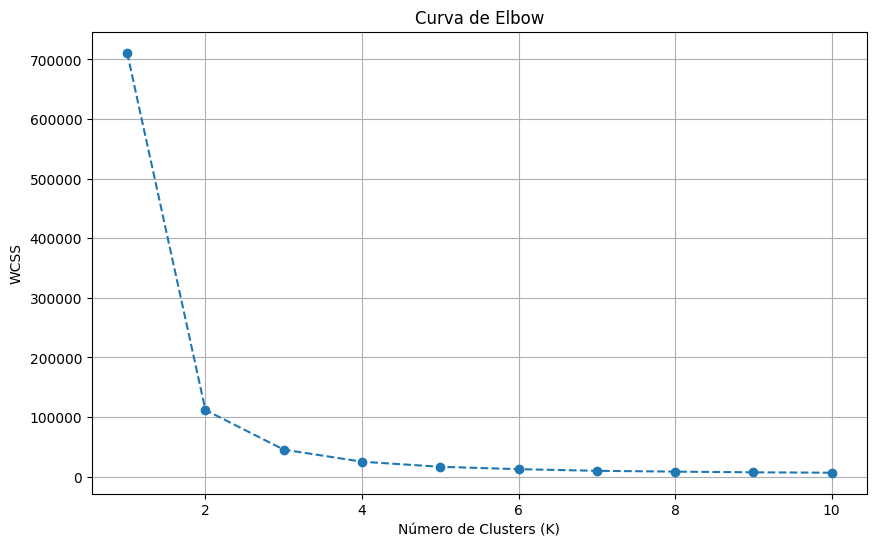

In [ ]:
from sklearn.cluster import KMeans

wcss = []
# Probar diferentes números de clusters de 1 a 10
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_clustering)
    wcss.append(kmeans.inertia_) # inertia_ es el WCSS

# Graficar el método del codo
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Curva de Elbow')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()


### **Silhouette Score**



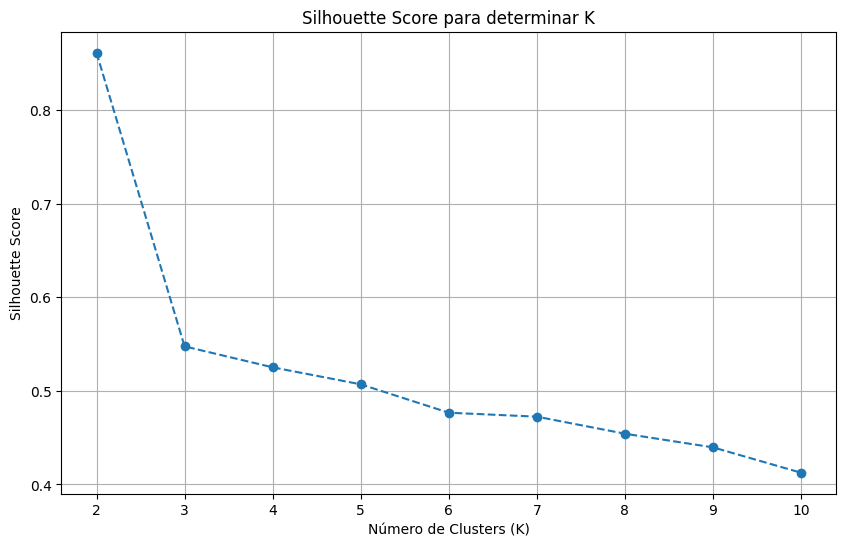

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
# Probar diferentes números de clusters de 2 a 10 (mínimo 2 para silueta)
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_clustering)
    score = silhouette_score(X_clustering, kmeans.labels_)
    silhouette_scores.append(score)

# Graficar Silhouette Score
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), silhouette_scores, marker='o', linestyle='--')
plt.title('Silhouette Score para determinar K')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

**Hallazgo**

Basado en los gráficos del Método Elbow y el Silhouette Score, el numero de cluster es 3, K = 3.

 **Entrenamiento del Modelo K-Means con K = 3**

Con base en el análisis previo del Método del Codo y el Coeficiente de Silueta, hemos determinado que el número óptimo de clusters es 3. Ahora, procederemos a entrenar el modelo K-Means con este valor de 'K' y asignaremos los clusters resultantes a nuestro DataFrame para un análisis posterior.

In [ ]:
# Entrenar el modelo K-Means con 3 clusters
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
kmeans.fit(X_clustering)

# Asignar las etiquetas de los clusters al DataFrame original
df_encoded['Cluster'] = kmeans.labels_

print("Modelo K-Means entrenado y clusters asignados al DataFrame.")
display(df_encoded[['Uso_TrimLinea_LOG', 'Prestamo_vigente_LOG', 'Uso_Linea_LOG', 'Cluster']].head())

# Mostrar el número de clientes en cada cluster
print("\nDistribución de clientes por cluster:")
display(df_encoded['Cluster'].value_counts().sort_index().to_frame(name='Conteo'))

Modelo K-Means entrenado y clusters asignados al DataFrame.


,Uso_TrimLinea_LOG,Prestamo_vigente_LOG,Uso_Linea_LOG,Cluster
0,0.000000,6.126869,0.000000,2
1,0.000000,9.323758,0.000000,1
2,0.203443,8.471987,0.357330,2
3,0.000000,0.000000,0.000000,0
4,0.088303,7.568379,0.140676,2



Distribución de clientes por cluster:


,Conteo
Cluster,
0,7560
1,43830
2,36166


In [ ]:
prediction = kmeans.predict(X_clustering)

In [ ]:
prediction

array([2, 1, 2, ..., 1, 1, 2], dtype=int32)

In [ ]:
pronosseg = pd.DataFrame(prediction, columns=['Cluster'])

In [ ]:
pronosseg.head(20)

,Cluster
0,2
1,1
2,2
3,0
4,2
5,2
6,2
7,2
8,2
9,2


In [ ]:
pronosseg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87556 entries, 0 to 87555
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Cluster  87556 non-null  int32
dtypes: int32(1)
memory usage: 342.1 KB


In [ ]:
data = df[['Uso_TrimLinea_LOG','Prestamo_vigente_LOG','Uso_Linea_LOG']]
data.head()

,Uso_TrimLinea_LOG,Prestamo_vigente_LOG,Uso_Linea_LOG
0,0.000000,6.126869,0.000000
1,0.000000,9.323758,0.000000
2,0.203443,8.471987,0.357330
3,0.000000,0.000000,0.000000
4,0.088303,7.568379,0.140676


In [ ]:
pd.concat([data, pronosseg], axis=1).head()

,Uso_TrimLinea_LOG,Prestamo_vigente_LOG,Uso_Linea_LOG,Cluster
0,0.000000,6.126869,0.000000,2
1,0.000000,9.323758,0.000000,1
2,0.203443,8.471987,0.357330,2
3,0.000000,0.000000,0.000000,0
4,0.088303,7.568379,0.140676,2


In [ ]:
#promedio
pd.concat([data, pronosseg], axis=1).groupby('Cluster').mean()

,Uso_TrimLinea_LOG,Prestamo_vigente_LOG,Uso_Linea_LOG
Cluster,,,
0,0.076092,0.000000,0.101231
1,0.095456,10.144433,0.116754
2,0.079600,8.312320,0.111633


In [ ]:
#suma
pd.concat([data, pronosseg], axis=1).groupby('Cluster').sum()

,Uso_TrimLinea_LOG,Prestamo_vigente_LOG,Uso_Linea_LOG
Cluster,,,
0,575.252926,0.000000,765.309586
1,4183.833928,444630.498928,5117.341191
2,2878.831422,300623.347252,4037.331691


**Dataset original (con las imputaciones)**

Se le agregan las variables categoricas y la tabla de pronostico (Dataset final)

In [ ]:
# Lista de columnas originales que tienen una versión _LOG y deben ser eliminadas
original_cols_to_drop = [
    'Uso_Linea', 'Uso_TrimLinea', 'Saldo_Consumo', 'SUELDO_ESTIMADO', 'ANTIGUEDAD_MES',
    'Linea_Renovado', 'Ahorro', 'Prestamo_vigente', 'Promed_6Mdeuda', 'Deuda_Cubierta%'
]

# Filtrar las columnas que realmente existen en df_encoded para evitar errores
existing_cols_to_drop = [col for col in original_cols_to_drop if col in df_encoded.columns]

# Eliminar las columnas originales del DataFrame df_encoded
df_final = df_encoded.drop(columns=existing_cols_to_drop)

print(f"Columnas eliminadas: {existing_cols_to_drop}")
print(f"El DataFrame final ahora tiene {df_final.shape[1]} columnas.")

# Mostrar las primeras filas del DataFrame final y sus columnas para verificar
display(df_final.head())
print("\nColumnas del DataFrame 'df_final':")
print(df_final.columns.tolist())

Columnas eliminadas: ['Uso_Linea', 'Uso_TrimLinea', 'Saldo_Consumo', 'SUELDO_ESTIMADO', 'ANTIGUEDAD_MES', 'Linea_Renovado', 'Ahorro', 'Prestamo_vigente', 'Promed_6Mdeuda', 'Deuda_Cubierta%']
El DataFrame final ahora tiene 43 columnas.


,MES,CLIENTE,Plazo_Renovado,FLAG_VENTA,Nro_Entidades,Dif_Entidades,Meses_oferta,EDAD,Flag_LimProv,Uso_Linea_LOG,...,SEXO_F,SEXO_M,EST_CIVIL_C,EST_CIVIL_D,EST_CIVIL_S,EST_CIVIL_U,EST_CIVIL_V,EST_CIVIL_X,EST_CIVIL_Y,Cluster
0,201506,1,12,0,1,-1,21.000000,25.0,1,0.000000,...,0,1,0,0,1,0,0,0,0,2
1,201506,2,6,0,1,0,9.000000,33.0,1,0.000000,...,0,1,0,0,1,0,0,0,0,1
2,201506,3,36,0,5,-2,11.867424,26.0,1,0.357330,...,0,1,0,0,1,0,0,0,0,2
3,201506,4,12,0,1,1,20.000000,51.0,0,0.000000,...,0,1,0,0,1,0,0,0,0,0
4,201506,5,36,1,1,0,11.000000,35.0,0,0.140676,...,0,1,1,0,0,0,0,0,0,2



Columnas del DataFrame 'df_final':
['MES', 'CLIENTE', 'Plazo_Renovado', 'FLAG_VENTA', 'Nro_Entidades', 'Dif_Entidades', 'Meses_oferta', 'EDAD', 'Flag_LimProv', 'Uso_Linea_LOG', 'Uso_TrimLinea_LOG', 'Saldo_Consumo_LOG', 'SUELDO_ESTIMADO_LOG', 'ANTIGUEDAD_MES_LOG', 'Linea_Renovado_LOG', 'Ahorro_LOG', 'Prestamo_vigente_LOG', 'Promed_6Mdeuda_LOG', 'Deuda_Cubierta%_LOG', 'REGION_CALLAO', 'REGION_CENTRO', 'REGION_LIMA BALNEARIO', 'REGION_LIMA CENTRO', 'REGION_LIMA ESTE', 'REGION_LIMA MODERNA', 'REGION_LIMA NORTE', 'REGION_LIMA PROVINCIA', 'REGION_LIMA SUR', 'REGION_NORTE', 'REGION_OESTE', 'REGION_ORIENTE', 'REGION_SIERRA CENTRAL', 'REGION_SUR', 'SEXO_F', 'SEXO_M', 'EST_CIVIL_C', 'EST_CIVIL_D', 'EST_CIVIL_S', 'EST_CIVIL_U', 'EST_CIVIL_V', 'EST_CIVIL_X', 'EST_CIVIL_Y', 'Cluster']


In [ ]:
#Validación de los resultados
df_final['Cluster'].value_counts()

,count
Cluster,
1,43830
2,36166
0,7560


In [ ]:
#Exportar base
df_final.to_csv("Resultado_renovacion_prestamo.xlsx", index=False)

Se crea un archivo excel, se descarga y se evalua los resultados con tablas dinamicas

## **5) Modelado**

Procederemos con la etapa de modelado utilizando el DataFrame 'df_final' que hemos preparado. Dividiremos los datos en un conjunto de entrenamiento y uno de prueba

In [ ]:
# Definir las características (X) y la variable objetivo (y)
X = df_final.drop(['FLAG_VENTA', 'MES', 'CLIENTE'], axis=1) # Excluir 'MES' y 'CLIENTE' ya que no son características predictivas directas
y = df_final['FLAG_VENTA']

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")
print(f"Dimensiones de y_train: {y_train.shape}")
print(f"Dimensiones de y_test: {y_test.shape}")

# Mostrar la distribución de la variable objetivo en los conjuntos de entrenamiento y prueba
print("\nDistribución de FLAG_VENTA en y_train:")
display(y_train.value_counts(normalize=True))
print("\nDistribución de FLAG_VENTA en y_test:")
display(y_test.value_counts(normalize=True))

Dimensiones de X_train: (61289, 40)
Dimensiones de X_test: (26267, 40)
Dimensiones de y_train: (61289,)
Dimensiones de y_test: (26267,)

Distribución de FLAG_VENTA en y_train:


,proportion
FLAG_VENTA,
0,0.960123
1,0.039877



Distribución de FLAG_VENTA en y_test:


,proportion
FLAG_VENTA,
0,0.960102
1,0.039898


In [ ]:
#Unir datos de X_train y Y_train
df_train = pd.concat([X_train, y_train], axis=1)
df_train.head()

,Plazo_Renovado,Nro_Entidades,Dif_Entidades,Meses_oferta,EDAD,Flag_LimProv,Uso_Linea_LOG,Uso_TrimLinea_LOG,Saldo_Consumo_LOG,SUELDO_ESTIMADO_LOG,...,SEXO_M,EST_CIVIL_C,EST_CIVIL_D,EST_CIVIL_S,EST_CIVIL_U,EST_CIVIL_V,EST_CIVIL_X,EST_CIVIL_Y,Cluster,FLAG_VENTA
53088,36,3,0,21.000000,46.0,1,0.000000,0.000000,9.253032,8.332287,...,1,1,0,0,0,0,0,0,1,0
64468,36,2,-1,13.720004,39.0,1,0.305522,0.000000,9.353575,8.200288,...,1,0,0,1,0,0,0,0,1,0
43153,36,2,0,6.000000,49.0,0,0.251177,0.033263,10.863327,6.908755,...,0,0,0,1,0,0,0,0,1,0
15665,36,2,0,21.000000,49.0,0,0.000000,0.000000,7.844511,9.086363,...,1,1,0,0,0,0,0,0,2,0
49438,18,2,-1,6.000000,42.0,1,0.399447,0.000000,9.203215,6.914731,...,1,0,0,1,0,0,0,0,2,0


In [ ]:
#Dividir en dataset de 0 y 1
count_class_0, count_class_1 = df_train.FLAG_VENTA.value_counts()
print(count_class_0, count_class_1)

58845 2444


In [ ]:
#Dividir mi conjunto de datos
df_class_0 = df_train[df_train['FLAG_VENTA'] == 0]
df_class_1 = df_train[df_train['FLAG_VENTA'] == 1]

In [ ]:
count_class_0, len(df_class_0), count_class_1, len(df_class_1)

(58845, 58845, 2444, 2444)

**UNDERSAMPLING**

In [ ]:
#Generas los registros aleatorios
df_class_0_under = df_class_0.sample(count_class_1, random_state=42)

#Vas a crear un nuevo dataset con los valores unificados
df_train_under = pd.concat([df_class_0_under, df_class_1], axis=0)

In [ ]:
df_train_under.FLAG_VENTA.value_counts()

,count
FLAG_VENTA,
0,2444
1,2444


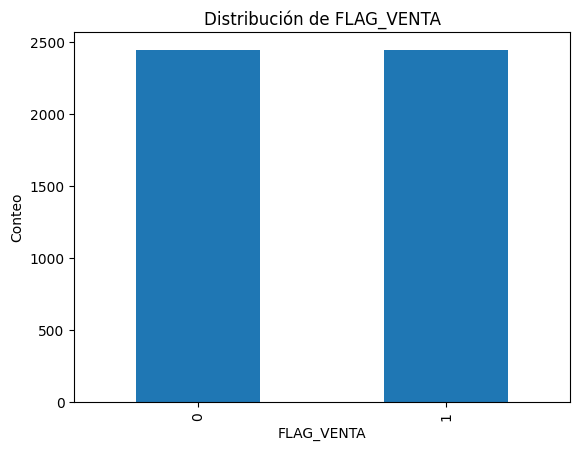

In [ ]:
df_train_under.FLAG_VENTA.value_counts().plot(kind='bar', title='Distribución de FLAG_VENTA')
plt.xlabel('FLAG_VENTA')
plt.ylabel('Conteo')
plt.show()

**OVERSAMPLING**

In [ ]:
# Generas los registros aleatorios
df_class_0_over = df_class_0.sample(count_class_1, replace=True, random_state=42)

# Vas a crear un nuevo dataset con los valores unificados
df_train_over = pd.concat([df_class_0_over, df_class_1], axis=0)

In [ ]:
df_train_over.FLAG_VENTA.value_counts()

,count
FLAG_VENTA,
0,2444
1,2444


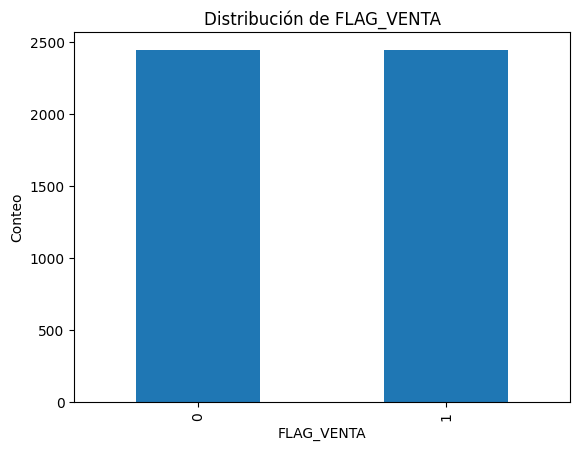

In [ ]:
df_train_over.FLAG_VENTA.value_counts().plot(kind='bar', title='Distribución de FLAG_VENTA')
plt.xlabel('FLAG_VENTA')
plt.ylabel('Conteo')
plt.show()

**SMOTE**

In [ ]:
pip install imblearn

In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
df_train.head()

,Plazo_Renovado,Nro_Entidades,Dif_Entidades,Meses_oferta,EDAD,Flag_LimProv,Uso_Linea_LOG,Uso_TrimLinea_LOG,Saldo_Consumo_LOG,SUELDO_ESTIMADO_LOG,...,SEXO_M,EST_CIVIL_C,EST_CIVIL_D,EST_CIVIL_S,EST_CIVIL_U,EST_CIVIL_V,EST_CIVIL_X,EST_CIVIL_Y,Cluster,FLAG_VENTA
53088,36,3,0,21.000000,46.0,1,0.000000,0.000000,9.253032,8.332287,...,1,1,0,0,0,0,0,0,1,0
64468,36,2,-1,13.720004,39.0,1,0.305522,0.000000,9.353575,8.200288,...,1,0,0,1,0,0,0,0,1,0
43153,36,2,0,6.000000,49.0,0,0.251177,0.033263,10.863327,6.908755,...,0,0,0,1,0,0,0,0,1,0
15665,36,2,0,21.000000,49.0,0,0.000000,0.000000,7.844511,9.086363,...,1,1,0,0,0,0,0,0,2,0
49438,18,2,-1,6.000000,42.0,1,0.399447,0.000000,9.203215,6.914731,...,1,0,0,1,0,0,0,0,2,0


In [ ]:
# Ejecucion completa del SMOTE
smote = SMOTE(k_neighbors=5, sampling_strategy='minority', random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
df_train_smote = pd.concat([X_resampled, y_resampled], axis=1)
df_train_smote.FLAG_VENTA.value_counts()

,count
FLAG_VENTA,
0,58845
1,58845


# **6) Evaluacion del Modelo**





# Modelo de Clasificacion utilizado es el arbol

**Datos Originales**

In [ ]:
#Llamar al modelo
model = DecisionTreeClassifier(random_state=42)

#Entrenar el modelo
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
#Prediccion del test
y_pred = model.predict(X_test)

#Calculo de Accurancy
accuracy = accuracy_score(y_true = y_test,y_pred = y_pred)
print('Accuracy del modelo con datos originales es de: %.2f%%' % (accuracy*100))

Accuracy del modelo con datos originales es de: 91.41%


In [ ]:
#Calculo de Matriz de confusión
print(10*'-','Matriz de confusión',10*'-')
print(confusion_matrix(y_true = y_test,y_pred = y_pred))
print(10*'-','Metricas del modelo',10*'-')
print(classification_report(y_true=y_test,y_pred=y_pred, digits = 3))

---------- Matriz de confusión ----------
[[23956  1263]
 [  994    54]]
---------- Metricas del modelo ----------
              precision    recall  f1-score   support

           0      0.960     0.950     0.955     25219
           1      0.041     0.052     0.046      1048

    accuracy                          0.914     26267
   macro avg      0.501     0.501     0.500     26267
weighted avg      0.923     0.914     0.919     26267



**Undersampling**

In [ ]:
# Adecuacion de X_train y y_train
X_train_u = df_train_under.drop('FLAG_VENTA', axis=1)
y_train_u = df_train_under['FLAG_VENTA']

# Llamar al modelo
model = DecisionTreeClassifier(random_state=42)

# Entrenar el modelo
model.fit(X_train_u, y_train_u)

# Prediccion del test
y_pred = model.predict(X_test)

# Calculo de Accurancy
accuracy = accuracy_score(y_true=y_test, y_pred=y_pred)
print('Accuracy del modelo con datos undersampleados es de: %.2f%%' % (accuracy * 100))

# Calculo de Matriz de confusión
print(10 * '-', 'Matriz de confusión', 10 * '-')
print(confusion_matrix(y_pred=y_pred, y_true=y_test))
print(10 * '-', 'Metricas del modelo', 10 * '-')
print(classification_report(y_pred=y_pred, y_true=y_test, digits = 3))


Accuracy del modelo con datos undersampleados es de: 55.50%
---------- Matriz de confusión ----------
[[13997 11222]
 [  467   581]]
---------- Metricas del modelo ----------
              precision    recall  f1-score   support

           0      0.968     0.555     0.705     25219
           1      0.049     0.554     0.090      1048

    accuracy                          0.555     26267
   macro avg      0.508     0.555     0.398     26267
weighted avg      0.931     0.555     0.681     26267



**Oversampling**

In [ ]:
# Adecuación de X_train y y_train
X_train_o = df_train_over.drop('FLAG_VENTA', axis=1)
y_train_o = df_train_over[['FLAG_VENTA']]

# Llamar al modelo
model = DecisionTreeClassifier(random_state=42)

# Entrenar el modelo
model.fit(X_train_o, y_train_o)

# Predicción del test
y_pred = model.predict(X_test)

# Cálculo de Accurancy
accuracy = accuracy_score(y_true=y_test, y_pred=y_pred)
print('Accuracy del modelo con datos oversampleados es de: %.2f%%' % (accuracy * 10))

# Calculo de Matriz de confusión
print(10 * '-', 'Matriz de confusión', 10 * '-')
print(confusion_matrix(y_true=y_test, y_pred=y_pred))
print(10 * '-', 'Metricas del modelo', 10 * '-')
print(classification_report(y_true=y_test, y_pred=y_pred, digits = 3))

Accuracy del modelo con datos oversampleados es de: 5.46%
---------- Matriz de confusión ----------
[[13799 11420]
 [  504   544]]
---------- Metricas del modelo ----------
              precision    recall  f1-score   support

           0      0.965     0.547     0.698     25219
           1      0.045     0.519     0.084      1048

    accuracy                          0.546     26267
   macro avg      0.505     0.533     0.391     26267
weighted avg      0.928     0.546     0.674     26267



**SMOTE**

In [ ]:
# Adecuacion de X_train y y_train
X_train_s = df_train_smote.drop('FLAG_VENTA', axis=1)
y_train_s = df_train_smote[['FLAG_VENTA']]

# Llamar al modelo
model = DecisionTreeClassifier(random_state=42)

# Entrenar el modelo
model.fit(X_train_s, y_train_s)

# Prediccion del test
y_pred = model.predict(X_test)

# Calculo de Accuracy
accuracy = accuracy_score(y_true=y_test, y_pred=y_pred)
print('Accuracy del modelo con datos SMOTE es de: %.2f%%' % (accuracy * 100))

# Calculo de Matriz de confusión
print(10 * '-', 'Matriz de confusión', 10 * '-')
print(confusion_matrix(y_true=y_test, y_pred=y_pred))
print(10 * '-', 'Metricas del modelo', 10 * '-')
print(classification_report(y_true=y_test, y_pred=y_pred, digits = 3))

Accuracy del modelo con datos SMOTE es de: 90.85%
---------- Matriz de confusión ----------
[[23786  1433]
 [  970    78]]
---------- Metricas del modelo ----------
              precision    recall  f1-score   support

           0      0.961     0.943     0.952     25219
           1      0.052     0.074     0.061      1048

    accuracy                          0.909     26267
   macro avg      0.506     0.509     0.506     26267
weighted avg      0.925     0.909     0.916     26267



Comparación

In [ ]:
metrics_original = {
    'Accuracy': 0.9141,
    'Precision': 0.049,
    'Recall': 0.554
}

metrics_undersampling = {
    'Accuracy': 0.5550,
    'Precision': 0.049,
    'Recall': 0.554
}

metrics_oversampling = {
    'Accuracy': 0.5527,
    'Precision': 0.045,
    'Recall': 0.519
}

metrics_smote = {
    'Accuracy': 0.9085,
    'Precision': 0.052,
    'Recall': 0.074
}

comparison_df = pd.DataFrame({
    'Original Data': metrics_original,
    'Undersampling': metrics_undersampling,
    'Oversampling': metrics_oversampling,
    'SMOTE': metrics_smote
})

# Transpose the DataFrame
transposed_df = comparison_df.T

# Convert 'Accuracy' to percentage and format
transposed_df.loc[:, 'Accuracy'] = transposed_df['Accuracy'] * 100

display(transposed_df.style.format({'Accuracy': '{:.2f}%', 'Precision': '{:.3f}', 'Recall': '{:.3f}'}))

,Accuracy,Precision,Recall
Original Data,91.41%,0.049,0.554
Undersampling,55.50%,0.049,0.554
Oversampling,55.27%,0.045,0.519
SMOTE,90.85%,0.052,0.074


**Hallazgo**

No me conviene ningun modelo, el objetivo es identificar correctamente si un cliente va a renovar. (Recall alto)
Y tambien no contactar demasiados clientes que no van a renovar (Precision alta).
Ninguno cumple estos parametros.

Ideal: Tener Recall Alto y Precision Alto.
Con esto se podria tener una mayor certeza de identificar clientes que van a renovar y no gastar recursos en clientes que no renuevan.

# **7) Ejecución de Modelos**

In [ ]:
# Obtener X_train e y_train
X_train_u = df_train_under.drop('FLAG_VENTA', axis=1)
y_train_u = df_train_under['FLAG_VENTA']

**XGBoost (Sin Tunear)**

In [ ]:
# Llamar al modelo
model1 = xgb.XGBClassifier(random_state=42)

# Entrenar el modelo
model1.fit(X_train_u, y_train_u)

# Prediccion
y_pred1 = model1.predict(X_test)

# Evaluación
print('Accuracy:')
print(accuracy_score(y_true=y_test, y_pred=y_pred1))
print('Reporte de confusion matrix')
print(confusion_matrix(y_true=y_test, y_pred=y_pred1))
print('Reporte de clasificación')
print(classification_report(y_true=y_test, y_pred=y_pred1,digits = 3))

Accuracy:
0.5806906003730917
Reporte de confusion matrix
[[14657 10562]
 [  452   596]]
Reporte de clasificación
              precision    recall  f1-score   support

           0      0.970     0.581     0.727     25219
           1      0.053     0.569     0.098      1048

    accuracy                          0.581     26267
   macro avg      0.512     0.575     0.412     26267
weighted avg      0.934     0.581     0.702     26267



**XGBoost (Tuneado)**

In [ ]:
# Llamar al modelo
model2 = xgb.XGBClassifier(random_state=42,n_estimators = 10, max_depth = 4, learning_rate=0.1,subsample = 0.5)

# Entrenar el modelo
model2.fit(X_train_u, y_train_u)

# Predicción
y_pred2 = model2.predict(X_test)

# Evaluación
print('Accuracy:')
print(accuracy_score(y_true=y_test, y_pred=y_pred2))
print('Reporte de confusion matrix')
print(confusion_matrix(y_true=y_test, y_pred=y_pred2))
print('Reporte de clasificación')
print(classification_report(y_true=y_test, y_pred=y_pred2,digits=3))

Accuracy:
0.5761602010126775
Reporte de confusion matrix
[[14485 10734]
 [  399   649]]
Reporte de clasificación
              precision    recall  f1-score   support

           0      0.973     0.574     0.722     25219
           1      0.057     0.619     0.104      1048

    accuracy                          0.576     26267
   macro avg      0.515     0.597     0.413     26267
weighted avg      0.937     0.576     0.698     26267



Random Forest (Sin Tunear)

In [ ]:
# Llamar al modelo
model3 = RandomForestClassifier(random_state=42)

# Entrenar el modelo
model3.fit(X_train_u, y_train_u)

# Predicción
y_pred3 = model3.predict(X_test)

# Evaluación
print('Accuracy:')
print(accuracy_score(y_true=y_test, y_pred=y_pred3))
print('Reporte de confusion matrix')
print(confusion_matrix(y_true=y_test, y_pred=y_pred3))
print('Reporte de clasificación')
print(classification_report(y_true=y_test, y_pred=y_pred3,digits=3))

Accuracy:
0.6011345033692466
Reporte de confusion matrix
[[15167 10052]
 [  425   623]]
Reporte de clasificación
              precision    recall  f1-score   support

           0      0.973     0.601     0.743     25219
           1      0.058     0.594     0.106      1048

    accuracy                          0.601     26267
   macro avg      0.516     0.598     0.425     26267
weighted avg      0.936     0.601     0.718     26267



Random Forest (Tuneado)

In [ ]:
# Llamar al modelo
model4 = RandomForestClassifier(random_state=42,n_estimators = 10, max_depth = 4)

# Entrenar el modelo
model4.fit(X_train_u, y_train_u)

# Predicción
y_pred4 = model4.predict(X_test)

# Evaluación
print('Accuracy:')
print(accuracy_score(y_true=y_test, y_pred=y_pred4))
print('Reporte de confusion matrix')
print(confusion_matrix(y_true=y_test, y_pred=y_pred4))
print('Reporte de clasificación')
print(classification_report(y_true=y_test, y_pred=y_pred4,digits=3))

Accuracy:
0.5660714965546122
Reporte de confusion matrix
[[14212 11007]
 [  391   657]]
Reporte de clasificación
              precision    recall  f1-score   support

           0      0.973     0.564     0.714     25219
           1      0.056     0.627     0.103      1048

    accuracy                          0.566     26267
   macro avg      0.515     0.595     0.409     26267
weighted avg      0.937     0.566     0.689     26267



In [ ]:
#Elección del Modelo
Tabla1 = pd.DataFrame({
    'Modelos': ['XGBoost (Sin Tuneo)', 'XGBoost (Tuneado)', 'Random Forest (Sin Tuneo)', 'Random Forest (Tuneado)', 'Arbol Decision'],
    'Accuracy': [58.07, 57.62, 60.11, 56.61, 91.41],
    'Precision': [0.053, 0.057, 0.058, 0.056, 0.049],
    'Recall': [0.569, 0.619, 0.594, 0.627,0.554]})

Tabla1

,Modelos,Accuracy,Precision,Recall
0,XGBoost (Sin Tuneo),58.07,0.053,0.569
1,XGBoost (Tuneado),57.62,0.057,0.619
2,Random Forest (Sin Tuneo),60.11,0.058,0.594
3,Random Forest (Tuneado),56.61,0.056,0.627
4,Arbol Decision,91.41,0.049,0.554


**Hallazgo**

El modelo o metodologia que debemos utilizar es
Random Forest (Tuneado).

## **Ajuste de Hiperparámetros con GridSearchCV**

'GridSearchCV' es una herramienta poderosa para encontrar la mejor combinación de hiperparámetros para un modelo. Evalúa todas las combinaciones posibles de un conjunto de hiperparámetros que definas y te permite seleccionar la que ofrece el mejor rendimiento según una métrica específica.

En este caso, lo usaremos para afinar el 'RandomForestClassifier' sobre los datos balanceados con Undersampling ('X_train_u', 'y_train_u'), prestando especial atención a las métricas de la clase minoritaria (la renovación de préstamos).

In [ ]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, recall_score, precision_score, f1_score, roc_auc_score, accuracy_score, confusion_matrix, classification_report
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans # Import KMeans for cluster assignment

# --- Aseguramos que X_train, y_train, X_test, y_test estén definidos ---

# 0. Load original dataframe (from cell C3KwisNjvFF6)
df = pd.read_csv('Dataset Renovacion_prestamo.csv',sep=";")

# 1. Renombrar columnas (from cell ukmbXrFe4P1Z)
df.rename(columns={
    'LINEA_RENOVADO':'Linea_Renovado',
    'PLAZO_RENOVADO':'Plazo_Renovado',
    'USO_LINEA_TOTAL_TC_T2':'Uso_Linea',
    'USO_TRIM_LINEA_BBVA':'Uso_TrimLinea',
    'NR_ENTIDADES_TOTAL_T2':'Nro_Entidades',
    'DIFF_NRO_ENTIDA_TOTALES_T2_T12':'Dif_Entidades',
    'SDO_CONSUMO_T2':'Saldo_Consumo',
    'RESENCIA_OFERTA_PLD_RENOVADO':'Meses_oferta',
    'Ahorro_Sldo_Bco_T1':'Ahorro',
    'PConsumo_Sldo_Bco_T1':'Prestamo_vigente',
    'SDO_BCO_tot_sm_pasivo_Bco_6M':'Promed_6Mdeuda',
    'FLAG_LIMA_PROVINCIA':'Flag_LimProv',
    'CUBRIR_DEUDA_CONSUMO_SF_RENOVA_PLD':'Deuda_Cubierta%'
}, inplace=True)

# 2. Capping y Transformación Logarítmica (from cells sJk5In58h3tJ, hBEMgLhRjtF0, ADNTgySbFRgt, 7d8OOFfyKvuu, E1C1xNsIRV-0)
# Capping para 'Ahorro', 'Prestamo_vigente', 'Promed_6Mdeuda'
df['Ahorro'] = np.maximum(0, df['Ahorro'])
df['Prestamo_vigente'] = np.maximum(0, df['Prestamo_vigente'])
df['Promed_6Mdeuda'] = np.maximum(0, df['Promed_6Mdeuda'])

variables_to_transform = [
    'Uso_Linea', 'Uso_TrimLinea', 'Saldo_Consumo', 'SUELDO_ESTIMADO', 'ANTIGUEDAD_MES',
    'Linea_Renovado', 'Ahorro', 'Prestamo_vigente', 'Promed_6Mdeuda', 'Deuda_Cubierta%'
]
for col_name in variables_to_transform:
    new_col_name = f'{col_name}_LOG'
    if col_name in df.columns:
        df[new_col_name] = np.log1p(df[col_name])

# 3. Imputación de Nulos (from cells 91337496, 7906a00d, kVGngyAQHxzN, 498oQajPp_Rm, a959ddd7, MQdziz0TsqIo, YCnN4VAgvFl6)
# Imputación para Uso_TrimLinea_LOG (sampling aleatorio)
mean_trim_log = df['Uso_TrimLinea_LOG'].mean()
std_trim_log = df['Uso_TrimLinea_LOG'].std()
lower_bound = mean_trim_log - std_trim_log
upper_bound = mean_trim_log + std_trim_log
null_indices = df['Uso_TrimLinea_LOG'].isnull()
num_nulls = null_indices.sum()
random_imputed_values = np.random.uniform(max(0, lower_bound), upper_bound, num_nulls)
df.loc[null_indices, 'Uso_TrimLinea_LOG'] = random_imputed_values

# Imputación para Uso_Linea_LOG (sampling aleatorio)
mean_linea_log_usage = df['Uso_Linea_LOG'].mean() # Renamed to avoid conflict
std_linea_log_usage = df['Uso_Linea_LOG'].std() # Renamed to avoid conflict
lower_bound_linea_usage = mean_linea_log_usage - std_linea_log_usage # Renamed to avoid conflict
upper_bound_linea_usage = mean_linea_log_usage + std_linea_log_usage # Renamed to avoid conflict
null_indices_linea_usage = df['Uso_Linea_LOG'].isnull() # Renamed to avoid conflict
num_nulls_linea_usage = null_indices_linea_usage.sum() # Renamed to avoid conflict
random_imputed_values_linea_usage = np.random.uniform(max(0, lower_bound_linea_usage), upper_bound_linea_usage, num_nulls_linea_usage) # Renamed to avoid conflict
df.loc[null_indices_linea_usage, 'Uso_Linea_LOG'] = random_imputed_values_linea_usage # Renamed to avoid conflict

# Imputación para Meses_oferta (sampling aleatorio)
mean_meses_oferta = df['Meses_oferta'].mean()
std_meses_oferta = df['Meses_oferta'].std()
lower_bound_meses_oferta = mean_meses_oferta - std_meses_oferta
upper_bound_meses_oferta = mean_meses_oferta + std_meses_oferta
null_indices_meses_oferta = df['Meses_oferta'].isnull()
num_nulls_meses_oferta = null_indices_meses_oferta.sum()
random_imputed_values_meses_oferta = np.random.uniform(max(0, lower_bound_meses_oferta), upper_bound_meses_oferta, num_nulls_meses_oferta)
df.loc[null_indices_meses_oferta, 'Meses_oferta'] = random_imputed_values_meses_oferta

# Imputación para Saldo_Consumo_LOG (mediana)
median_saldo_consumo_log = df['Saldo_Consumo_LOG'].median()
df['Saldo_Consumo_LOG'] = df['Saldo_Consumo_LOG'].fillna(median_saldo_consumo_log)

# Imputación para SUELDO_ESTIMADO_LOG (mediana)
median_sueldo_log = df['SUELDO_ESTIMADO_LOG'].median()
df['SUELDO_ESTIMADO_LOG'] = df['SUELDO_ESTIMADO_LOG'].fillna(median_sueldo_log)

# Imputación para ANTIGUEDAD_MES_LOG (mediana)
median_antiguedad_log = df['ANTIGUEDAD_MES_LOG'].median() # Renamed for clarity
df['ANTIGUEDAD_MES_LOG'] = df['ANTIGUEDAD_MES_LOG'].fillna(median_antiguedad_log)

# Imputación para EDAD (mediana)
median_edad = df['EDAD'].median() # Renamed for clarity
df['EDAD'] = df['EDAD'].fillna(median_edad)

# Imputación de nulos para variables categóricas (from cells 057cbbd3, 29a70f61, e9203168)
for col in ['REGION', 'SEXO', 'EST_CIVIL']:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)

# 4. Re-create df_encoded (from cell 64415b1f) - now with fully prepared 'df'
categorical_cols = ['REGION', 'SEXO', 'EST_CIVIL']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=False, dtype=int)

# 5. Add 'Cluster' column to df_encoded (from cell 98e43ed1 and its dependencies)
#    First, define clustering features (from cell d05b7615)
selected_clustering_features = ['Uso_TrimLinea_LOG', 'Prestamo_vigente_LOG', 'Uso_Linea_LOG']
X_clustering = df_encoded[selected_clustering_features].copy()

#    Handle any NaN that might have remained (from cell d05b7615)
X_clustering = X_clustering.fillna(X_clustering.median())

#    Train KMeans and assign labels (from cell 98e43ed1)
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
kmeans.fit(X_clustering)
df_encoded['Cluster'] = kmeans.labels_

# Now, df_final can be created (from cell da5fe715)
original_cols_to_drop = [
    'Uso_Linea', 'Uso_TrimLinea', 'Saldo_Consumo', 'SUELDO_ESTIMADO', 'ANTIGUEDAD_MES',
    'Linea_Renovado', 'Ahorro', 'Prestamo_vigente', 'Promed_6Mdeuda', 'Deuda_Cubierta%'
]
existing_cols_to_drop = [col for col in original_cols_to_drop if col in df_encoded.columns]
df_final = df_encoded.drop(columns=existing_cols_to_drop)

# Definir las características (X) y la variable objetivo (y)
X = df_final.drop(['FLAG_VENTA', 'MES', 'CLIENTE'], axis=1) # Excluir 'MES' y 'CLIENTE' ya que no son características predictivas directas
y = df_final['FLAG_VENTA']

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
# -----------------------------------------------------------------------

# Aseguramos la creación de df_train_under dentro de esta celda
# Primero, volvemos a crear df_train a partir de X_train y y_train
df_train = pd.concat([X_train, y_train], axis=1)

# Luego, obtenemos los conteos de las clases
count_class_0, count_class_1 = df_train.FLAG_VENTA.value_counts()

# Dividimos en datasets de clase 0 y clase 1
df_class_0 = df_train[df_train['FLAG_VENTA'] == 0]
df_class_1 = df_train[df_train['FLAG_VENTA'] == 1]

# Realizamos el undersampling para la clase mayoritaria
df_class_0_under = df_class_0.sample(count_class_1, random_state=42)

# Concatenamos para crear el conjunto de entrenamiento undersampleado
df_train_under = pd.concat([df_class_0_under, df_class_1], axis=0)

# Obtener X_train e y_train undersampleados
X_train_u = df_train_under.drop('FLAG_VENTA', axis=1)
y_train_u = df_train_under['FLAG_VENTA']

# Definimos las métricas que nos interesan para la clase positiva (FLAG_VENTA = 1)
# Usamos make_scorer para poder pasarlos a GridSearchCV
scoring = {
    'roc_auc': make_scorer(roc_auc_score),
    'recall_pos': make_scorer(recall_score, pos_label=1),
    'precision_pos': make_scorer(precision_score, pos_label=1),
    'f1_pos': make_scorer(f1_score, pos_label=1)
}

# Definimos los hiperparámetros a buscar
param_grid = {
    'n_estimators': [50, 100, 150],  # Número de árboles en el bosque
    'max_depth': [None, 10, 20],   # Profundidad máxima del árbol
    'min_samples_leaf': [1, 2, 4], # Número mínimo de muestras requeridas para estar en un nodo hoja
    'class_weight': ['balanced']   # Para manejar el desbalance de clases
}

# Creamos el modelo base de RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)

# Inicializamos GridSearchCV
# refit='f1_pos' significa que el modelo final se entrenará con la combinación de parámetros que maximice el F1-Score de la clase positiva.
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    scoring=scoring,
    refit='f1_pos', # Refit con la métrica f1_pos para optimizar el balance entre recall y precision de la clase 1
    cv=3, # Número de folds para la validación cruzada
    verbose=2, # Nivel de verbosidad
    n_jobs=-1  # Usa todos los núcleos disponibles
)

# Entrenamos el GridSearchCV con los datos de entrenamiento undersampleados
print("Iniciando GridSearchCV...")
grid_search.fit(X_train_u, y_train_u)
print("GridSearchCV completado.")

# Mostramos los mejores parámetros encontrados
print("\nMejores parámetros encontrados:")
print(grid_search.best_params_)

# Mostramos la mejor puntuación obtenida con estos parámetros
print("\nMejor F1-Score (clase 1) en validación cruzada:", grid_search.best_score_)

# Obtenemos el mejor modelo
best_rf_model = grid_search.best_estimator_

# Hacemos predicciones con el mejor modelo en el conjunto de prueba (X_test)
y_pred_best_rf = best_rf_model.predict(X_test)

# Evaluamos el mejor modelo con las métricas deseadas
print('\n--- Evaluación del Mejor Modelo de Random Forest (GridSearchCV) ---\n')
print(f"Accuracy: {accuracy_score(y_test, y_pred_best_rf):.2f}")
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_best_rf))
print("\nReporte de Clasificación (para clase 1):")
print(classification_report(y_test, y_pred_best_rf, digits=3))

Iniciando GridSearchCV...
Fitting 3 folds for each of 27 candidates, totalling 81 fits
GridSearchCV completado.

Mejores parámetros encontrados:
{'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 150}

Mejor F1-Score (clase 1) en validación cruzada: 0.6247583701746885

--- Evaluación del Mejor Modelo de Random Forest (GridSearchCV) ---

Accuracy: 0.61

Matriz de Confusión:
[[15361  9858]
 [  408   640]]

Reporte de Clasificación (para clase 1):
              precision    recall  f1-score   support

           0      0.974     0.609     0.750     25219
           1      0.061     0.611     0.111      1048

    accuracy                          0.609     26267
   macro avg      0.518     0.610     0.430     26267
weighted avg      0.938     0.609     0.724     26267



**Hallazgos**

- Despues de usar GridSearchCV mejoro los parametros como:
 Precision: 0.061
 Recall: 0.611
 Accuracy: 61%

 Aumenta la capacidad de identificar la mayoria de las renovaciones (Recall), pero la precision sigue sien baja (Precision), lo que significa que de todas las predicciones de renovacion, solo un pequeño porcentaje sera correcta.

# **La predicción con nuevos datos**








In [ ]:
df_encoded.head(2)

,MES,CLIENTE,LINEA_RENOVADO,PLAZO_RENOVADO,FLAG_VENTA,USO_LINEA_TOTAL_TC_T2,USO_TRIM_LINEA_BBVA,NR_ENTIDADES_TOTAL_T2,DIFF_NRO_ENTIDA_TOTALES_T2_T12,SDO_CONSUMO_T2,...,REGION_SUR,SEXO_F,SEXO_M,EST_CIVIL_C,EST_CIVIL_D,EST_CIVIL_S,EST_CIVIL_U,EST_CIVIL_V,EST_CIVIL_X,EST_CIVIL_Y
0,201506,1,3770,12,0,0.0,0.0,1,-1,271.12,...,0,0,1,0,0,1,0,0,0,0
1,201506,2,1300,6,0,0.0,0.0,1,0,11200.00,...,0,0,1,0,0,1,0,0,0,0


In [ ]:
X_train_u.head()
X_train_u.columns

Index(['Plazo_Renovado', 'Nro_Entidades', 'Dif_Entidades', 'Meses_oferta',
       'EDAD', 'Flag_LimProv', 'Uso_Linea_LOG', 'Uso_TrimLinea_LOG',
       'Saldo_Consumo_LOG', 'SUELDO_ESTIMADO_LOG', 'ANTIGUEDAD_MES_LOG',
       'Linea_Renovado_LOG', 'Ahorro_LOG', 'Prestamo_vigente_LOG',
       'Promed_6Mdeuda_LOG', 'Deuda_Cubierta%_LOG', 'REGION_CALLAO',
       'REGION_CENTRO', 'REGION_LIMA BALNEARIO', 'REGION_LIMA CENTRO',
       'REGION_LIMA ESTE', 'REGION_LIMA MODERNA', 'REGION_LIMA NORTE',
       'REGION_LIMA PROVINCIA', 'REGION_LIMA SUR', 'REGION_NORTE',
       'REGION_OESTE', 'REGION_ORIENTE', 'REGION_SIERRA CENTRAL', 'REGION_SUR',
       'SEXO_F', 'SEXO_M', 'EST_CIVIL_C', 'EST_CIVIL_D', 'EST_CIVIL_S',
       'EST_CIVIL_U', 'EST_CIVIL_V', 'EST_CIVIL_X', 'EST_CIVIL_Y', 'Cluster'],
      dtype='object')

In [ ]:
# Definimos un conjunto de datos ficticios
datos_dummy = pd.DataFrame({'Plazo_Renovado':[12],
                            'Nro_Entidades':[3],
                            'Dif_Entidades':[0],
                            'Meses_oferta':[6],
                            'EDAD':[34],
                            'Flag_LimProv':[0],
                            'Uso_Linea_LOG':[0.440676],
                            'Uso_TrimLinea_LOG':[0.440676],
                            'Saldo_Consumo_LOG':[8.88],
                            'SUELDO_ESTIMADO_LOG':[8.134],
                            'ANTIGUEDAD_MES_LOG':[5],
                            'Linea_Renovado_LOG':[1500],
                            'Ahorro_LOG':[2093],
                            'Prestamo_vigente_LOG':[18.512],
                            'Promed_6Mdeuda_LOG':[8.051],
                            'Deuda_Cubierta%_LOG':[0.67],
                            'REGION_CALLAO':[0],
                            'REGION_CENTRO':[1],
                            'REGION_LIMA BALNEARIO':[0],
                            'REGION_LIMA CENTRO':[0],
                            'REGION_LIMA ESTE':[0],
                            'REGION_LIMA MODERNA':[0],
                            'REGION_LIMA NORTE':[0],
                            'REGION_LIMA PROVINCIA':[0],
                            'REGION_LIMA SUR':[0],
                            'REGION_NORTE':[0],
                            'REGION_OESTE':[0],
                            'REGION_ORIENTE':[0],
                            'REGION_SIERRA CENTRAL':[0],
                            'REGION_SUR':[0],
                            'SEXO_F':[0],
                            'SEXO_M':[1],
                            'EST_CIVIL_C':[1],
                            'EST_CIVIL_D':[0],
                            'EST_CIVIL_S':[0],
                            'EST_CIVIL_U':[0],
                            'EST_CIVIL_V':[0],
                            'EST_CIVIL_X':[0],
                            'EST_CIVIL_Y':[0],
                            'Cluster':[1]})

In [ ]:
datos_dummy

,Plazo_Renovado,Nro_Entidades,Dif_Entidades,Meses_oferta,EDAD,Flag_LimProv,Uso_Linea_LOG,Uso_TrimLinea_LOG,Saldo_Consumo_LOG,SUELDO_ESTIMADO_LOG,...,SEXO_F,SEXO_M,EST_CIVIL_C,EST_CIVIL_D,EST_CIVIL_S,EST_CIVIL_U,EST_CIVIL_V,EST_CIVIL_X,EST_CIVIL_Y,Cluster
0,12,3,0,6,34,0,0.440676,0.440676,8.88,8.134,...,0,1,1,0,0,0,0,0,0,1


In [ ]:
print(model4.predict_proba(datos_dummy))
print(model4.predict(datos_dummy))


[[0.41456184 0.58543816]]
[1]


**Hallazgos**


*   Segun el model con los datos seteados existe un 58.5% de que el cliente renueve su prestamo.

